# Análise de dados de Sistema de Monitoramento

O presente trabalho tem como objetivo analisar os dados das avaliações Somativas aplicadas em todo o programa PBA Sergipe (incluindo turmas do aditivo de contrato) para entender a eficácia pedagógica do programa através de seus instrumentos.

## Importando bibliotecas e dados

In [1]:
# Importando bibliotecas
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np
import textwrap
from scipy.stats import chi2_contingency, wilcoxon

# Importando arquivo
df_alfabetizandos_se = pd.read_excel(
    'Data_files/public_data/xls_dados_alfabetizandos_17122025.xlsx')
df_cadastro = pd.read_excel(
    'Data_files/public_data/xls_pedagogico_04122025.xlsx')
df_turmas = pd.read_excel(
    'Data_files/public_data/turmas_04122025.xlsx')
df_registros = pd.read_excel(
    'Data_files/public_data/xls_detalhado_04122025.xlsx')
df_relatorios_diagnostica = pd.read_excel(
    'Data_files/public_data/relatorios_turmas_diagnostica_04122025.xlsx')
df_relatorios_formativa1 = pd.read_excel(
    'Data_files/public_data/relatorios_turmas_formativa1_04122025.xlsx')
df_relatorios_formativa2 = pd.read_excel(
    'Data_files/public_data/relatorios_turmas_formativa2_04122025.xlsx')
df_relatorios_formativa3 = pd.read_excel(
    'Data_files/public_data/relatorios_turmas_formativa3_04122025.xlsx')
df_relatorios_formativa4 = pd.read_excel(
    'Data_files/public_data/relatorios_turmas_formativa4_04122025.xlsx')
df_relatorios_somativa = pd.read_excel(
    'Data_files/public_data/relatorios_turmas_somativa_04122025.xlsx')

print('df_alfabetizandos_se:')
print(df_alfabetizandos_se.info())
#print(df_alfabetizandos_se.head())

print('df_cadastro:')
print(df_cadastro.info())
#print(df_cadastro.head())

print('df_turmas:')
print(df_turmas.info())
#print(df_turmas.head())

print('df_registros:')
print(df_registros.info())
#print(df_registros.head())

print('df_relatorios_diagnostica:')
print(df_relatorios_diagnostica.info())
#print(df_relatorios_diagnostica.head())

print('df_relatorios_formativa1:')
print(df_relatorios_formativa1.info())
#print(df_relatorios_formativa1.head())

print('df_relatorios_formativa2:')
print(df_relatorios_formativa2.info())
#print(df_relatorios_formativa2.head())

print('df_relatorios_formativa3:')
print(df_relatorios_formativa3.info())
#print(df_relatorios_formativa3.head())

print('df_relatorios_formativa4:')
print(df_relatorios_formativa4.info())
#print(df_relatorios_formativa4.head())

print('df_relatorios_somativa:')
print(df_relatorios_somativa.info())
#print(df_relatorios_somativa.head())


df_alfabetizandos_se:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11273 entries, 0 to 11272
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   CPF                 11273 non-null  object
 1   Nome                11273 non-null  object
 2   Telefone            11043 non-null  object
 3   Data de nascimento  8899 non-null   object
 4   DRE                 11246 non-null  object
 5   Município           11246 non-null  object
 6   Bairro              9698 non-null   object
 7   Endereço completo   9430 non-null   object
 8   Turno               11273 non-null  object
 9   E-mail              7995 non-null   object
 10  Turma               11273 non-null  object
 11  Data de inserção    11273 non-null  object
 12  CPF validado        8968 non-null   object
dtypes: object(13)
memory usage: 1.1+ MB
None
df_cadastro:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4577 entries, 0 to 4576
Data columns (to

## Tratando dos dados
Se faz necessário a transformação dos dados para que seja mais fácil sua análise. De acordo com a observação dos dados apresentados, as seguintes transformações serão necessárias:
Em df_registros:
- Transformar nomes de cada coluna para o padrão snake_case;
- Extrair somente os níveis da coluna "Nível";
- Deixar os níveis de maneira categórica corretamente para melhor análise na coluna "Nível".

Em df_relatorios
- Transformar nomes de cada coluna para o padrão snake_case;
- As colunas que contém perguntas serão reduzidas somente a palavra "pergunta" seguida do seu número, exemplo: pergunta_1
- As categorias de resposta serão resumidas em no máximo 3 palavras para facilitar a interpretação - um dicionário será criado aqui.

Em df_cadastro, df_turmas, df_relatorios_(diagnostica / formativa1, 2 e 3):
- Todas as colunas que contem datas deverão ser tranformados para o tipo datetime.

In [2]:
# Transformando nomes de colunas para padrão snake_case
# Função para converter para snake_case
def to_snake_case(column_name):
    return (
        column_name
        .lower()  # Converte tudo para minúsculo
        .replace(' ', '_')  # Substitui espaços por underscore
        .replace('é', 'e')  # Remove acentos
        .replace('ã', 'a')
        .replace('ç', 'c')
        .replace('í', 'i')
        .replace('ó', 'o')
        .replace('ú', 'u')
        .replace('á', 'a')
    )

# Função para extrair o número de perguntas e renomear
def renomear_perguntas(nome_coluna):
    match = re.match(r'^(\d+)\._', nome_coluna)  # Procura o padrão "X._" no início
    if match:
        numero = match.group(1)
        return f'pergunta_{numero}'
    return nome_coluna  # Mantém o nome original se não for uma pergunta numerada

# Aplica a função to_snake_case aos nomes das colunas
df_alfabetizandos_se.columns = [to_snake_case(col) for col in df_alfabetizandos_se.columns]
df_cadastro.columns = [to_snake_case(col) for col in df_cadastro.columns]
df_turmas.columns = [to_snake_case(col) for col in df_turmas.columns]
df_registros.columns = [to_snake_case(col) for col in df_registros.columns]
df_relatorios_diagnostica.columns = [to_snake_case(col) for col in df_relatorios_diagnostica.columns]
df_relatorios_formativa1.columns = [to_snake_case(col) for col in df_relatorios_formativa1.columns]
df_relatorios_formativa2.columns = [to_snake_case(col) for col in df_relatorios_formativa2.columns]
df_relatorios_formativa3.columns = [to_snake_case(col) for col in df_relatorios_formativa3.columns]
df_relatorios_formativa4.columns = [to_snake_case(col) for col in df_relatorios_formativa4.columns]
df_relatorios_somativa.columns = [to_snake_case(col) for col in df_relatorios_somativa.columns]

# Aplica a função renomear_perguntas a todas as colunas
df_relatorios_diagnostica.columns = [renomear_perguntas(col) for col in df_relatorios_diagnostica.columns]
df_relatorios_somativa.columns = [renomear_perguntas(col) for col in df_relatorios_somativa.columns]

# Extraindo somente os dados de nível em df_registros
df_registros['nivel'] = df_registros['nivel'].str.extract(r'(Nível [1-3])')

# Ordenando nívels de maneira categórica corretamente
df_registros['nivel'] = pd.Categorical(
    df_registros['nivel'],
    categories=['Nível 1', 'Nível 2', 'Nível 3'],
    ordered=True)

# Verificando os tipos de dados e informações das colunas
#print(df_cadastro.info())
#print(df_turmas.info())
#print(df_registros.info())
#print(df_relatorios_diagnostica.info())


In [3]:
# Checando turmas encerradas para serem excluidas da análise
turmas_encerradas = df_turmas[df_turmas['situacao_da_turma'] == 'Encerrada']['turma'].tolist()
print(f"Número de turmas encerradas: {len(turmas_encerradas)}")

Número de turmas encerradas: 15


Temos um total de 15 que devem ser retiradas dos dfs, além disso, temos mais 65 turmas que precisarão ser retiradas da análise por terem sido incluídas no aditivo do contrato (30) e terem sido analisadas em relatórios separados (35). Assim, vamos criar mais duas listas, adicionar na lista retirar_turmas e, de fato, retirar os dados dessas turmas dos dfs.

In [4]:
# Inclusão na lista de turmas para retirada
retirar_turmas = list(set(turmas_encerradas))

# Imprimindo resultado da lista completa
print(f'Número de turmas a serem retiradas: {len(retirar_turmas)}')
print(f'Códigos das turmas a serem retiradas: {retirar_turmas}')


Número de turmas a serem retiradas: 15
Códigos das turmas a serem retiradas: ['TURMA-28018389-0005', 'TURMA-28032578-0004', 'TURMA-28028562-0003', 'TURMA-28018575-0015', 'TURMA-28031911-0002', 'TURMA-28019180-0006', 'TURMA-28021223-0013', 'TURMA-28020472-0004', 'TURMA-P0000004-0001', 'TURMA-28031911-0003', 'TURMA-28026667-0026', 'TURMA-28018508-0009', 'TURMA-28032225-0006', 'TURMA-28010132-0003', 'TURMA-28009983-0002']


Nota: Observa-se que um total de 80 foram retiradas.

Em seguida, vamos retirar os dados das turmas de todos os dataframes, porém vamos criar uma cópia de df_registros com a totalidade de turmas para elaboração de gráfico com total de turmas por município.

In [5]:
# Função para retirar turmas
def remover_turmas(df, coluna_turma='turma', turmas_para_remover=None):
    """
    Remove linhas do DataFrame onde a coluna de turma está na lista de turmas para remover.
    
    Parâmetros:
    - df: DataFrame do pandas
    - coluna_turma: Nome da coluna que contém os códigos das turmas (padrão: 'turma')
    - turmas_para_remover: Lista de códigos de turmas a serem removidas
    
    Retorna:
    - DataFrame com as turmas removidas
    """
    if turmas_para_remover is None:
        return df
    
    # Verifica se a coluna existe no DataFrame
    if coluna_turma not in df.columns:
        print(f"Aviso: Coluna '{coluna_turma}' não encontrada no DataFrame.")
        return df
    
    # Filtra o DataFrame mantendo apenas as linhas onde a turma não está na lista de remoção
    df_filtrado = df[~df[coluna_turma].isin(turmas_para_remover)].copy()
    
    return df_filtrado

# Criando cópia de df_registros antes de remover turmas para análise posterior
df_turmas_completo = df_turmas.copy()

# Removendo turmas dos DataFrames
df_alfabetizandos_se = remover_turmas(df_alfabetizandos_se, 'turma', retirar_turmas)
df_cadastro = remover_turmas(df_cadastro, 'turma', retirar_turmas)
df_turmas = remover_turmas(df_turmas, 'turma', retirar_turmas)
df_registros = remover_turmas(df_registros, 'turma', retirar_turmas)
df_relatorios_diagnostica = remover_turmas(df_relatorios_diagnostica, 'turma', retirar_turmas)
df_relatorios_formativa1 = remover_turmas(df_relatorios_formativa1, 'turma', retirar_turmas)
df_relatorios_formativa2 = remover_turmas(df_relatorios_formativa2, 'turma', retirar_turmas)
df_relatorios_formativa3 = remover_turmas(df_relatorios_formativa3, 'turma', retirar_turmas)
df_relatorios_formativa4 = remover_turmas(df_relatorios_formativa4, 'turma', retirar_turmas)
df_relatorios_somativa = remover_turmas(df_relatorios_somativa, 'turma', retirar_turmas)

#df_registros[df_registros['municipio'] == 'Aracaju']['turma'].nunique()


Agora vamos retirar valores não preenchidos para Data de Nascimento.

In [6]:
# Removendo NaNs
df_alfabetizandos_se.dropna(subset=['data_de_nascimento'], inplace=True)

# Consertando erros de digitação detectados
df_alfabetizandos_se['data_de_nascimento'] = df_alfabetizandos_se['data_de_nascimento'].str.replace(r'/(14|09|00|10)(\d{2})', r'/19\2', regex=True)
df_alfabetizandos_se['data_de_nascimento'] = df_alfabetizandos_se['data_de_nascimento'].str.replace('/1901', '/2001')


Agora vamos alterar as colunas com datas para o formato correto.

In [7]:
# Transformando colunas de data para o tipo datetime
df_alfabetizandos_se['data_de_nascimento'] = pd.to_datetime(df_alfabetizandos_se["data_de_nascimento"], format="%d/%m/%Y")
df_alfabetizandos_se['data_de_insercao'] = pd.to_datetime(df_alfabetizandos_se["data_de_insercao"], format="%d/%m/%Y")
df_cadastro['data_de_inicio'] = pd.to_datetime(df_cadastro["data_de_inicio"], format="%d/%m/%Y")
df_turmas['data_inicio'] = pd.to_datetime(df_turmas["data_inicio"], format="%d/%m/%Y")
df_relatorios_diagnostica['data_de_lancamento'] = pd.to_datetime(df_relatorios_diagnostica["data_de_lancamento"], format="%d/%m/%Y")
df_relatorios_formativa1['data_de_lancamento'] = pd.to_datetime(df_relatorios_formativa1["data_de_lancamento"], format="%d/%m/%Y")
df_relatorios_formativa2['data_de_lancamento'] = pd.to_datetime(df_relatorios_formativa2["data_de_lancamento"], format="%d/%m/%Y")
df_relatorios_formativa3['data_de_lancamento'] = pd.to_datetime(df_relatorios_formativa3["data_de_lancamento"], format="%d/%m/%Y")
df_relatorios_formativa4['data_de_lancamento'] = pd.to_datetime(df_relatorios_formativa4["data_de_lancamento"], format="%d/%m/%Y")
df_relatorios_somativa['data_de_lancamento'] = pd.to_datetime(df_relatorios_somativa["data_de_lancamento"], format="%d/%m/%Y")

# Verificando os tipos de dados e informações das colunas
#print(df_cadastro.info())
#print(df_turmas.info())
#print(df_relatorios_diagnostica.info())
#print(df_relatorios_formativa1.info())
#print(df_relatorios_formativa2.info())
#print(df_relatorios_formativa3.info())

In [8]:
# Extraindo o ano de nascimento dos alfabetizandos
df_alfabetizandos_se['ano_nascimento'] = df_alfabetizandos_se['data_de_nascimento'].dt.year

# Calculando a idade dos alfabetizandos considerando o ano de 2025
df_alfabetizandos_se['idade'] = 2025 - df_alfabetizandos_se['ano_nascimento']

# Excluindo dados de alunos menores de 15 anos
alfabetizandos_menores_de_15 = df_alfabetizandos_se[df_alfabetizandos_se['idade'] < 15]
df_alfabetizandos_se = df_alfabetizandos_se[df_alfabetizandos_se['idade'] > 14]

# Verificando tamanho da amostra
print(f'Alfabetizandos menores de 15 anos: {len(alfabetizandos_menores_de_15)}')
print(f'Alfabetizando com dados completos: {len(df_alfabetizandos_se)}')


Alfabetizandos menores de 15 anos: 59
Alfabetizando com dados completos: 8840


In [9]:
# Mantendo somente dados de alunos enturmados
df_alfabetizandos_enturmados = df_alfabetizandos_se[df_alfabetizandos_se['turma'] != '-'].copy()
df_alfabetizandos_enturmados.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4567 entries, 20 to 11272
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   cpf                 4567 non-null   object        
 1   nome                4567 non-null   object        
 2   telefone            4566 non-null   object        
 3   data_de_nascimento  4567 non-null   datetime64[ns]
 4   dre                 4567 non-null   object        
 5   municipio           4567 non-null   object        
 6   bairro              4553 non-null   object        
 7   endereco_completo   4552 non-null   object        
 8   turno               4567 non-null   object        
 9   e-mail              4252 non-null   object        
 10  turma               4567 non-null   object        
 11  data_de_insercao    4567 non-null   datetime64[ns]
 12  cpf_validado        4564 non-null   object        
 13  ano_nascimento      4567 non-null   int32         


Vamos verificar se há alguma turma que não apresenta resultados de atividades

In [10]:
# Comparando turmas em df_registros e df_turmas
turmas = set(df_turmas['turma'].unique().tolist())
turmas_registros = set(df_registros['turma'].unique().tolist())

print(turmas - turmas_registros)

print(len(turmas_registros))

set()
333


Turmas encerradas foram retiradas com sucesso.
Dessa forma serão analisados resultados de 268 turmas somente.

Agora vamos organizar as turmas de acordo com a fase que cada uma se encontra:

In [11]:
# Criando dfs para cada avaliação realizada
df_registros_diag = df_registros[df_registros['atividade'] == 'ATIVIDADE ESTRUTURADA DIAGNÓSTICA – RETRATO DE ENTRADA']
df_registros_form_1 = df_registros[df_registros['atividade'] == 'ATIVIDADE ESTRUTURADA FORMATIVA 1']
df_registros_form_2 = df_registros[df_registros['atividade'] == 'ATIVIDADE ESTRUTURADA FORMATIVA 2']
df_registros_form_3 = df_registros[df_registros['atividade'] == 'ATIVIDADE ESTRUTURADA FORMATIVA 3']
df_registros_form_4 = df_registros[df_registros['atividade'] == 'ATIVIDADE ESTRUTURADA FORMATIVA 4']
df_registros_soma = df_registros[df_registros['atividade'] == 'ATIVIDADE ESTRUTURADA SOMATIVA - RETRATO DA SAÍDA\n']


## Entendendo os dados
Aqui vamos entender cada coluna das tabelas e descrever cada uma delas para melhor entender os dados:

df_registros:
- cpf: representa o CPF dos alunos
- nome: representa o nome completo do aluno;
- turma: código da turma do aluno;
- municipio: nome do município da turma;
- atividade: atividade estruturada realizada;
- linguagem: práticas de linguagem de acordo com objetivos da aprendizagem localizados na matriz de referência (Oralidade e leitura; Análise Linguística; Produção de texto)
- aprendizagem: Prática avaliativa - itens analisados por nível pelo professor após a correção da atividade (varia entre atividades estruturadas)
- nivel: nível de classificação que vai de 1 a 3.

df_relatorios_diagnostica:
- alfabetizador: nome do alfabetizador responsável pela turma;
- turma: código unívoco da turma;
- data_de_lancamento: data de lançamento do relatório;
- pergunta_1: O que os motiva a voltar a estudar?
- pergunta_2: Quais as perspectivas da turma quanto a alfabetização e ao letramento?
- pergunta_3: Quanto ao interesse pelo processo de alfabetização, a turma:
- pergunta_4: A turma consegue realizar atividades propostas de forma independente?
- pergunta_5: O que a turma faz quando sente que não está entendendo alguma coisa?
- pergunta_6: Como a turma reage diante de erros ou falhas?
- pergunta_7: Como os(as) alfabetizandos(as) se comportam durante as atividades em grupo?
- pergunta_8: Quanto a leitura de palavras simples e escrita de sílabas e letras, a observação inicial é de que a turma tem:
- pergunta_9: Em relação a aplicação do conhecimento em situações prática, a turma apresenta:
- pergunta_10: Como os(as) alfabetizandos(as) valorizam o saber no seu dia a dia?

## Estudando os dados gerais: analisando o programa como um todo.
Agora vamos entender como os dados gerais estão se comportando. Os objetivos aqui são:
- Entender qual número total de alunos;
- Entender qual o número total de turmas;
- Entender qual o número médio de alunos por turma;
- Entender quantas turmas estão estudando cada unidade do livro (1, 2, 3 ou 4), no estado todo e por município.
- Entender os resultados dos alunos em cada atividade avaliativa de maneira geral, verificando os resultados e relacionando-os com a matriz de referência;
- Fazer comparativos para entender evolução dos alunos, comparando Formativas em suas devidas Práticas de Linguagem, no estado e em cada município;
- Entender se está havendo evolução ou não dos alunos. 

In [12]:
# Entendendo número total de alunos enturmados
enturmados = df_cadastro['nome'].count()

# Entendendo número de turmas totais
n_turmas = df_turmas['turma'].nunique()

# Entendendo número médio de alunos por turma
media_alunos_por_turma = enturmados / n_turmas

# Entendendo número de turmas com registros de formativa 4
turmas_com_registros_somativa = df_registros[df_registros['atividade'] == 'ATIVIDADE ESTRUTURADA SOMATIVA - RETRATO DA SAÍDA\n']['turma'].nunique()

# Impirmindo resultados
print(f"Número total de alunos estudando: {enturmados}")
print(f"Número total de turmas iniciadas: {n_turmas}")
print(f"Número médio de alunos por turma: {media_alunos_por_turma:.2f}")
print(f"Número de turmas com registros de somativa: {turmas_com_registros_somativa}")


Número total de alunos estudando: 4577
Número total de turmas iniciadas: 333
Número médio de alunos por turma: 13.74
Número de turmas com registros de somativa: 333


In [13]:
# Entendendo número de registros em cada turma para Somativa
contagem_por_turma = df_cadastro.groupby('turma')['atividade_-_saida'].count()

# Listando turmas sem dados
sem_dados = contagem_por_turma[contagem_por_turma == 0].index.tolist()
com_dados = contagem_por_turma[contagem_por_turma > 0].index.tolist()

# Imprimindo resultados
print(f"Número de turmas com dados de somativa:{len(com_dados)}")
print(f"Número de turmas sem dados de somativa:{len(sem_dados)}")
print()
print(f"Turmas sem dados de somativa:{sem_dados}")
print()
print(contagem_por_turma)

Número de turmas com dados de somativa:331
Número de turmas sem dados de somativa:0

Turmas sem dados de somativa:[]

turma
TURMA-28000013-0001    16
TURMA-28000013-0002    16
TURMA-28000013-0003    16
TURMA-28000013-0004    16
TURMA-28000013-0005    16
                       ..
TURMA-P0000122-0001    14
TURMA-P0000122-0002     9
TURMA-P0000123-0001    12
TURMA-P0000135-0001    14
TURMA-P0000136-0001    18
Name: atividade_-_saida, Length: 331, dtype: int64


In [14]:
turmas_somativa = contagem_por_turma.index.tolist()
total_turmas = df_turmas['turma'].unique().tolist()

print(list(set(total_turmas) - set(turmas_somativa)))

['TURMA-28013298-0004', 'TURMA-28013298-0005']


Vamos a quantidade de turmas que estão estudando cada unidade no presente momento no programa como um todo e por município.

In [15]:
# Primeiro, vamos criar um dicionário com a ordem hierárquica das atividades
ordem_atividades = {
    'ATIVIDADE ESTRUTURADA SOMATIVA - RETRATO DA SAÍDA\n': 6,
    'ATIVIDADE ESTRUTURADA FORMATIVA 4': 5,
    'ATIVIDADE ESTRUTURADA FORMATIVA 3': 4,
    'ATIVIDADE ESTRUTURADA FORMATIVA 2': 3,
    'ATIVIDADE ESTRUTURADA FORMATIVA 1': 2,
    'ATIVIDADE ESTRUTURADA DIAGNÓSTICA – RETRATO DE ENTRADA': 1
}

# Para cada turma, encontramos a atividade mais avançada que ela realizou
turmas_atividades = df_registros.groupby('turma')['atividade'].apply(
    lambda x: max(x.unique(), key=lambda a: ordem_atividades.get(a, 0))
).reset_index()

# Agora classificamos as turmas conforme sua atividade mais avançada
ls_turmas_finalizadas = set(turmas_atividades[turmas_atividades['atividade'] == 'ATIVIDADE ESTRUTURADA SOMATIVA - RETRATO DA SAÍDA\n']['turma'])
ls_turmas_somativa = set(turmas_atividades[turmas_atividades['atividade'] == 'ATIVIDADE ESTRUTURADA FORMATIVA 4']['turma'])
ls_turmas_unid_4 = set(turmas_atividades[turmas_atividades['atividade'] == 'ATIVIDADE ESTRUTURADA FORMATIVA 3']['turma'])
ls_turmas_unid_3 = set(turmas_atividades[turmas_atividades['atividade'] == 'ATIVIDADE ESTRUTURADA FORMATIVA 2']['turma'])
ls_turmas_unid_2 = set(turmas_atividades[turmas_atividades['atividade'] == 'ATIVIDADE ESTRUTURADA FORMATIVA 1']['turma'])
ls_turmas_unid_1 = set(turmas_atividades[turmas_atividades['atividade'] == 'ATIVIDADE ESTRUTURADA DIAGNÓSTICA – RETRATO DE ENTRADA']['turma'])

# Verificação - todas as turmas devem estar em exatamente uma lista
total_turmas_classificadas = (len(ls_turmas_finalizadas) + len(ls_turmas_somativa) + len(ls_turmas_unid_4) + 
                            len(ls_turmas_unid_3) + len(ls_turmas_unid_2) + len(ls_turmas_unid_1))
print(f"Total de turmas classificadas: {total_turmas_classificadas}")
print(f"Total de turmas no dataframe: {df_registros['turma'].nunique()}")


Total de turmas classificadas: 333
Total de turmas no dataframe: 333


In [16]:
# Criamos o DataFrame base com todos os municípios únicos
turmas_por_unidade = pd.DataFrame(df_registros['municipio'].unique(), columns=['municipio'])

# Função auxiliar para contar turmas e garantir todos municípios
def contar_turmas(df, turmas, nome_coluna):
    contagem = (df[df['turma'].isin(turmas)]
               .groupby('municipio')['turma']
               .nunique()
               .reset_index()
               .rename(columns={'turma': nome_coluna}))
    
    # Fazemos o merge mantendo todos os municípios originais
    resultado = pd.merge(turmas_por_unidade, contagem, on='municipio', how='left')
    resultado[nome_coluna] = resultado[nome_coluna].fillna(0).astype('int64')
    return resultado

# Aplicamos para cada lista de turmas
turmas_por_unidade = contar_turmas(df_registros_diag, ls_turmas_unid_1, 'turmas_em_unid_1')
turmas_por_unidade = contar_turmas(df_registros_diag, ls_turmas_unid_2, 'turmas_em_unid_2')
turmas_por_unidade = contar_turmas(df_registros_diag, ls_turmas_unid_3, 'turmas_em_unid_3')
turmas_por_unidade = contar_turmas(df_registros_diag, ls_turmas_unid_4, 'turmas_em_unid_4')
turmas_por_unidade = contar_turmas(df_registros_diag, ls_turmas_somativa, 'turmas_em_somativa')
turmas_por_unidade = contar_turmas(df_registros_diag, ls_turmas_finalizadas, 'turmas_finalizadas')
turmas_por_unidade = turmas_por_unidade.sort_values(by='municipio', ascending=True).reset_index(drop=True)

# Entendendo quantidade de turmas por município
turmas_por_unidade['total_turmas'] = turmas_por_unidade[['turmas_em_unid_1', 'turmas_em_unid_2', 
                                                       'turmas_em_unid_3', 'turmas_em_unid_4', 'turmas_em_somativa', 'turmas_finalizadas']].sum(axis=1)


print(f'Checando total de turmas: {turmas_por_unidade['total_turmas'].sum()}')
turmas_por_unidade


Checando total de turmas: 332


,municipio,turmas_em_unid_1,turmas_em_unid_2,turmas_em_unid_3,turmas_em_unid_4,turmas_em_somativa,turmas_finalizadas,total_turmas
0,Aquidabã,0,0,0,0,0,4,4
1,Aracaju,0,0,0,0,0,50,50
2,Areia Branca,0,0,0,0,0,4,4
3,Boquim,0,0,0,0,0,6,6
4,Canindé de São Francisco,0,0,0,0,0,8,8
5,Capela,0,0,0,0,0,13,13
6,Carira,0,0,0,0,0,5,5
7,Cristinápolis,0,0,0,0,0,4,4
8,Estância,0,0,0,0,0,3,3
9,Frei Paulo,0,0,0,0,0,2,2


In [17]:
# Análise com df completo antes de remoção de turmas
turmas_por_municipio_completo = df_turmas_completo.groupby('municipio')['turma'].nunique().reset_index().rename(columns={'turma': 'total_turmas'})
print(f'Há um total de {turmas_por_municipio_completo['total_turmas'].sum()} turmas')
turmas_por_municipio_completo

Há um total de 348 turmas


,municipio,total_turmas
0,AQUIDABÃ,4
1,ARACAJU,57
2,AREIA BRANCA,4
3,BOQUIM,6
4,CANINDÉ DE SÃO FRANCISCO,9
5,CAPELA,13
6,CARIRA,5
7,CRISTINÁPOLIS,4
8,ESTÂNCIA,3
9,FREI PAULO,2


/tmp/ipykernel_72170/4019107223.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=turmas_por_municipio_completo.sort_values('total_turmas', ascending=False),


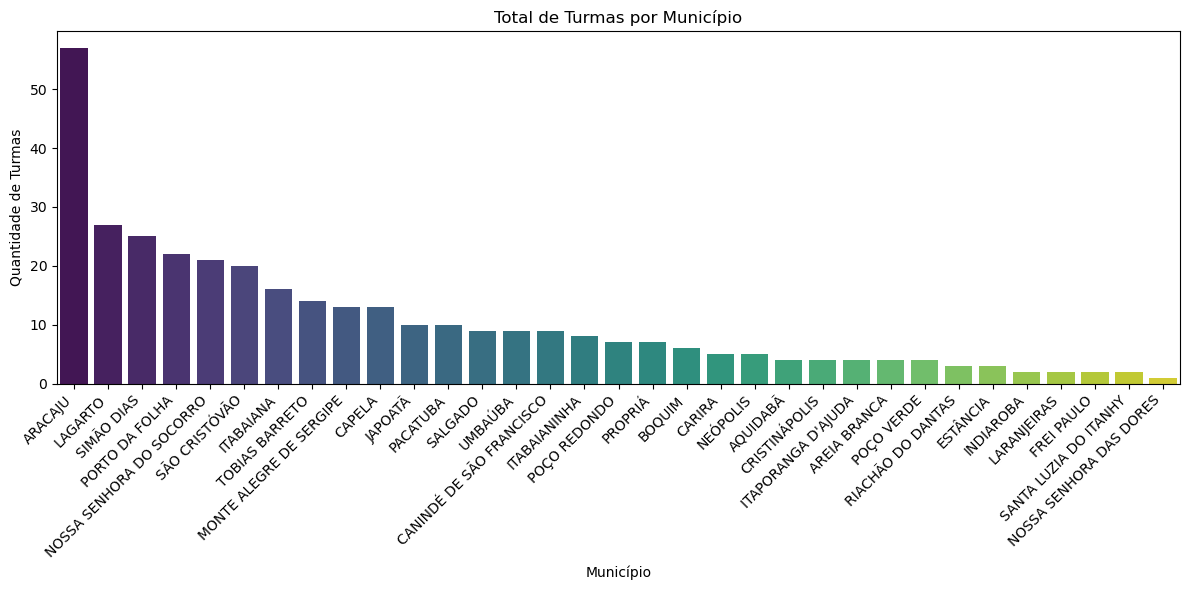

In [18]:
# Criando diretório para salvar os gráficos
output_dir_somativa = "Data_files/graficos_somativa_348_turmas"
os.makedirs(output_dir_somativa, exist_ok=True)

# Criando gráfico de total de turmas por município
plt.figure(figsize=(12, 6))
sns.barplot(data=turmas_por_municipio_completo.sort_values('total_turmas', ascending=False),
            x='municipio', y='total_turmas', palette='viridis')
plt.title('Total de Turmas por Município')
plt.xlabel('Município')
plt.ylabel('Quantidade de Turmas')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f'{output_dir_somativa}/total_por_municipio.png', dpi=300)
plt.show()

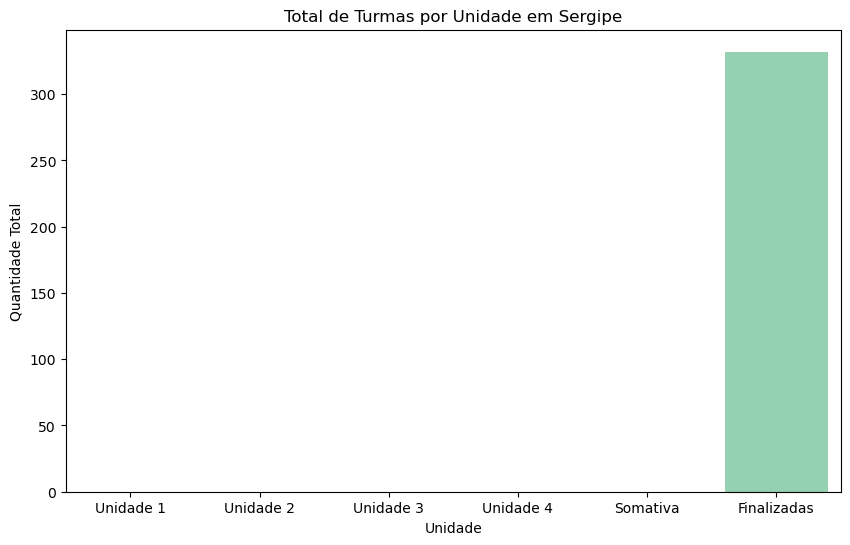

,Unidade,Quantidade
0,Finalizadas,332
1,Somativa,0
2,Unidade 1,0
3,Unidade 2,0
4,Unidade 3,0
5,Unidade 4,0


In [19]:
# Criando gráfico de total de turmas em cada unidade
# Gráfico 2: Total de turmas por unidade (com rótulos personalizados)
df_unidades = turmas_por_unidade.melt(
    id_vars=['municipio'],
    value_vars=['turmas_em_unid_1', 'turmas_em_unid_2', 'turmas_em_unid_3', 'turmas_em_unid_4', 'turmas_em_somativa', 'turmas_finalizadas'],
    var_name='Unidade',
    value_name='Quantidade'
)

# Mapear nomes das unidades
mapeamento_unidades = {
    'turmas_em_unid_1': 'Unidade 1',
    'turmas_em_unid_2': 'Unidade 2',
    'turmas_em_unid_3': 'Unidade 3',
    'turmas_em_unid_4': 'Unidade 4',
    'turmas_em_somativa': 'Somativa',
    'turmas_finalizadas': 'Finalizadas'
}
df_unidades['Unidade'] = df_unidades['Unidade'].map(mapeamento_unidades)

# Plotar o gráfico (sem warnings!)
plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_unidades,
    x='Unidade',
    y='Quantidade',
    hue='Unidade',      # Adicionado para evitar o warning
    estimator=sum,
    errorbar=None,
    palette='mako',
    legend=False        # Remove legenda redundante
)
plt.title('Total de Turmas por Unidade em Sergipe')
plt.xlabel('Unidade')
plt.ylabel('Quantidade Total')
plt.savefig(f'{output_dir_somativa}/total_turmas_por_unidade_sergipe.png', dpi=300)
#plt.close()
plt.show()

df_unidades.groupby('Unidade')['Quantidade'].sum().reset_index()

In [20]:
# Criando um gráfico por município para mostrar número de turmas em cada unidade
# Criar um gráfico para cada município
for municipio in turmas_por_unidade['municipio'].unique():
    # Filtrar dados do município
    df_municipio = turmas_por_unidade[turmas_por_unidade['municipio'] == municipio]
    
    # Transformar os dados para formato longo (melt) e aplicar mapeamento
    df_melted = df_municipio.melt(
        id_vars=['municipio'], 
        value_vars=['turmas_em_unid_1', 'turmas_em_unid_2', 'turmas_em_unid_3', 'turmas_em_unid_4', 'turmas_em_somativa', 'turmas_finalizadas'],
        var_name='Unidade', 
        value_name='Quantidade'
    )
    
    # Aplicar os novos nomes das unidades
    df_melted['Unidade'] = df_melted['Unidade'].map(mapeamento_unidades)
    
    # Ordenar as unidades
    df_melted['Unidade'] = pd.Categorical(
        df_melted['Unidade'],
        categories=['Unidade 1', 'Unidade 2', 'Unidade 3', 'Unidade 4', 'Somativa', 'Finalizadas'],
        ordered=True
    )
    
    # Configurar o gráfico (versão atualizada do Seaborn)
    plt.figure(figsize=(8, 5))
    sns.barplot(
        data=df_melted,
        x='Unidade',
        y='Quantidade',
        hue='Unidade',  # Adicionado para evitar o warning
        palette='rocket',
        legend=False    # Não mostra a legenda redundante
    )
    
    # Adicionar título e rótulos
    plt.title(f'Distribuição de Turmas em {municipio}')
    plt.xlabel('Unidade')
    plt.ylabel('Quantidade de Turmas')
    
    # Salvar o gráfico
    nome_arquivo = f"turmas_por_unidade_{municipio.lower().replace(' ', '_').replace('ã', 'a').replace('ç', 'c')}.png"
    plt.tight_layout()
    plt.savefig(f'{output_dir_somativa}/{nome_arquivo}', dpi=300)
    plt.close()


### Entendendo idade dos estudantes

In [21]:
# 1. Estatísticas de idade por Município (Mínima, Máxima e Média)
# Agrupamos por município e calculamos as métricas na coluna 'idade'
stats_municipio = df_alfabetizandos_enturmados.groupby('municipio')['idade'].agg(['min', 'max', 'mean']).reset_index()

# Renomeando as colunas para ficar mais claro
stats_municipio.columns = ['municipio', 'idade_minima', 'idade_maxima', 'media_de_idade']

# Arredondando a média para 1 casa decimal
stats_municipio['media_de_idade'] = stats_municipio['media_de_idade'].round(1)

print("Estatísticas por Município:")
print(stats_municipio)

Estatísticas por Município:
                   municipio  idade_minima  idade_maxima  media_de_idade
0                   AQUIDABÃ            15            89            52.3
1                    ARACAJU            15            90            51.4
2               AREIA BRANCA            15            89            53.3
3                     BOQUIM            17            90            58.5
4   CANINDÉ DE SÃO FRANCISCO            16            90            52.7
5                     CAPELA            15            90            49.8
6                     CARIRA            15            90            48.3
7              CRISTINÁPOLIS            16            90            52.7
8                   ESTÂNCIA            15            85            53.6
9                 FREI PAULO            16            87            42.6
10                 INDIAROBA            15            88            56.9
11                 ITABAIANA            15            90            52.6
12              ITABAIA

In [22]:
# 2. Criação das Faixas Etárias
# Definimos os limites dos intervalos (bins) e os nomes (labels)
bins = [
    14,             # Borda 0 (0 a 14 anos)
    24,             # Borda 1 (15 a 24 anos)
    34,             # Borda 2 (25 a 34 anos)
    44,             # Borda 3 (35 a 44 anos)
    54,             # Borda 4 (45 a 54 anos)
    64,             # Borda 5 (55 a 64 anos)
    74,             # Borda 6 (65 a 74 anos)
    float('inf')    # Borda 7 (mais de 74 anos)
]

# Definindo categorias para cada faixa de idade
age_categories = [
    '15 a 24 anos',
    '25 a 34 anos',
    '35 a 44 anos',
    '45 a 54 anos',
    '55 a 64 anos',
    '65 a 74 anos',
    '75 anos ou mais'
]

# Criamos a nova coluna usando pd.cut
# right=False garante que o intervalo seja [15, 25), ou seja, de 15 até 24.
df_alfabetizandos_enturmados['faixa_etaria'] = pd.cut(
    df_alfabetizandos_enturmados['idade'], 
    bins=bins, 
    labels=age_categories, 
    right=False
)

# 3. Criar a contagem de faixas etárias por município (Pivot Table)
faixas_por_mun = pd.crosstab(
    df_alfabetizandos_enturmados['municipio'], 
    df_alfabetizandos_enturmados['faixa_etaria']
).reset_index()

# 4. Juntar as duas tabelas em um único relatório final
relatorio_final = pd.merge(stats_municipio, faixas_por_mun, on='municipio', how='outer')

# Exibir o resultado
relatorio_final

,municipio,idade_minima,idade_maxima,media_de_idade,15 a 24 anos,25 a 34 anos,35 a 44 anos,45 a 54 anos,55 a 64 anos,65 a 74 anos,75 anos ou mais
0,AQUIDABÃ,15,89,52.3,7,3,10,5,5,9,10
1,ARACAJU,15,90,51.4,97,89,86,87,83,76,155
2,AREIA BRANCA,15,89,53.3,9,9,7,3,13,10,16
3,BOQUIM,17,90,58.5,4,8,3,11,8,7,21
4,CANINDÉ DE SÃO FRANCISCO,16,90,52.7,14,20,14,16,23,23,23
5,CAPELA,15,90,49.8,24,21,13,12,22,25,23
6,CARIRA,15,90,48.3,15,8,15,4,17,9,13
7,CRISTINÁPOLIS,16,90,52.7,4,7,6,6,9,3,10
8,ESTÂNCIA,15,85,53.6,4,6,3,7,6,9,8
9,FREI PAULO,16,87,42.6,4,3,5,1,2,2,2


In [23]:
# Configurações de cores e faixas
faixas_etarias = ['15 a 24 anos', '25 a 34 anos', '35 a 44 anos', 
                  '45 a 54 anos', '55 a 64 anos', '65 a 74 anos', '75 anos ou mais']
cores = plt.cm.Set3.colors # Paleta de cores suave e distinta

if not os.path.exists(output_dir_somativa):
    os.makedirs(output_dir_somativa)

# Loop para cada município
for index, row in relatorio_final.iterrows():
    municipio = row['municipio']
    valores = row[faixas_etarias]
    
    if valores.sum() == 0: continue

    # Criando a figura com espaço para a legenda
    fig, ax = plt.subplots(figsize=(12, 7))
    
    # Criando a pizza sem labels internos, apenas porcentagem
    wedges, texts, autotexts = ax.pie(
        valores, 
        autopct='%1.1f%%', 
        startangle=140, 
        colors=cores,
        pctdistance=0.85 # Afasta as porcentagens do centro
    )
    
    # Adicionando a legenda à direita
    ax.legend(
        wedges, 
        faixas_etarias,
        title="Faixas Etárias",
        loc="center left",
        bbox_to_anchor=(1, 0, 0.5, 1) # Posiciona a legenda fora do gráfico
    )

    plt.title(f'Distribuição por Faixa Etária - {municipio}', fontsize=15, pad=20)
    
    # Salvando com bbox_inches='tight' para não cortar a legenda
    nome_arquivo = f"pizza_legenda_{municipio.replace(' ', '_')}.png"
    plt.savefig(os.path.join(output_dir_somativa, nome_arquivo), dpi=300, bbox_inches='tight')
    plt.close(fig)


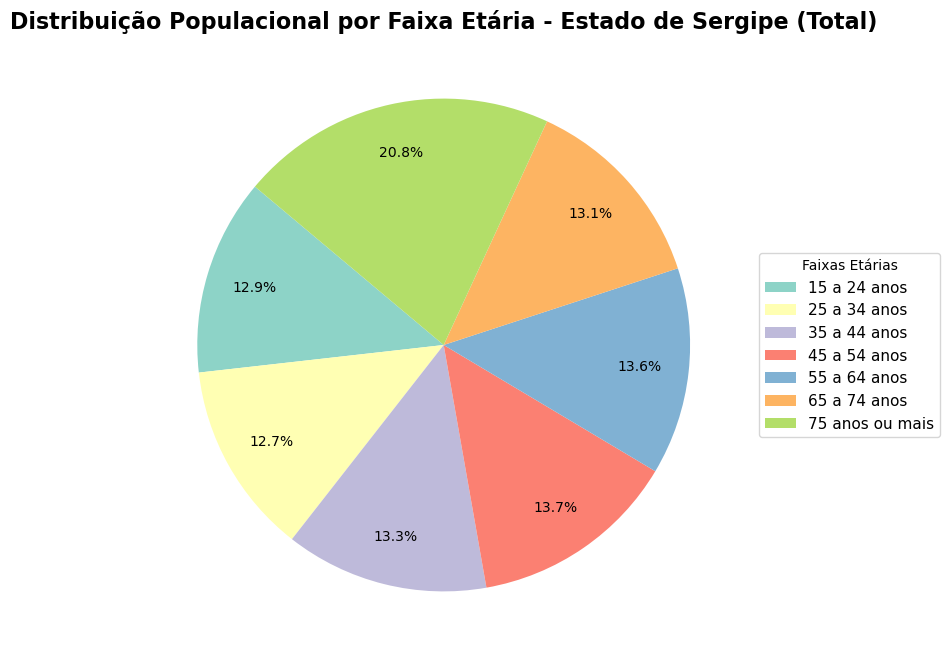

In [24]:
# Somando os valores totais do estado
totais_estado = relatorio_final[faixas_etarias].sum()

fig, ax = plt.subplots(figsize=(12, 8))

wedges, texts, autotexts = ax.pie(
    totais_estado, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=cores,
    pctdistance=0.80
)

# Legenda lateral para o Estado
ax.legend(
    wedges, 
    faixas_etarias,
    title="Faixas Etárias",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1),
    fontsize=11
)

plt.title('Distribuição Populacional por Faixa Etária - Estado de Sergipe (Total)', fontsize=16, fontweight='bold')

# Salvando o gráfico do estado
plt.savefig(os.path.join(output_dir_somativa, 'pizza_total_estado_Sergipe.png'), dpi=300, bbox_inches='tight')
plt.show()


In [25]:
# Modificando nomes de colunas para exportar tabela
novos_nomes = {
    'municipio': 'Município',
    'idade_minima': 'Idade Mínima',
    'idade_maxima': 'Idade Máxima',
    'media_de_idade': 'Média de Idade'
}

relatorio_final = relatorio_final.rename(columns=novos_nomes)

# Exportando relatório final para Excel
relatorio_final.to_excel(f'{output_dir_somativa}/relatorio_idade_alfabetizandos_por_municipio.xlsx', index=False)


##### Estudando os dados por estado
Agora vamos entender os dados de cada município. Dessa forma, nosso objetivo aqui é:
- Entender a quantidade de alunos por município e sua proporção em relação ao programa como um todo;
- Entender a quantidade de turmas por município e sua proporção em relação ao programa como um todo;
- Entender a relevância dos alunos perante o total de alunos enturmados em Sergipe;
- Gerar os resultados dos registros por atividade estruturada por município;
- Gerar os resultados de perfil de turma por município e entender se os perfis são diferentes.

##### Entendendo alunos e turmas por município


#### Atividade Estruturada Formativa 1

Primeiramente, vamos construir uma tabela contando as quantidades de cada nível para cada formativa, considerando a linguagem, municipio e a turma.

In [26]:
# Calculando moda dos níveis para cada linguagem
def calcular_moda_nivel(df, form_number):
    """
    Calcula a moda da coluna 'nivel' para um dataframe de formulário específico.
    
    Args:
        df: DataFrame com os registros do formulário
        form_number: Número do formulário (1, 2, 3, 4 ou 5 para somativa)
    
    Returns:
        DataFrame com as modas calculadas
    """
    moda_df = (
        df.groupby(['cpf', 'nome', 'turma', 'municipio', 'linguagem'])['nivel']
        .agg(lambda x: x.mode().iloc[0])
        .reset_index()
    )
    return moda_df

# Calcular modas para cada formulário
moda_form_1 = calcular_moda_nivel(df_registros_form_1, 1)
moda_form_2 = calcular_moda_nivel(df_registros_form_2, 2)
moda_form_3 = calcular_moda_nivel(df_registros_form_3, 3)
moda_form_4 = calcular_moda_nivel(df_registros_form_4, 4)
moda_somativa = calcular_moda_nivel(df_registros_soma, 5)

# Contando níveis por formativa
def contar_niveis_por_form(df, form_number):
    # Conta a ocorrência de cada nível, mantendo as colunas de agrupamento
    # Adicionando observed=True para evitar o warning
    contagem = (
        df.groupby(['turma', 'municipio', 'linguagem', 'nivel'], observed=True)
        .size()
        .unstack(fill_value=0)
        .reset_index()
    )
    
    # Renomeia as colunas de nível para incluir o número do formulário
    nivel_cols = [col for col in contagem.columns if col not in ['turma', 'municipio', 'linguagem']]
    rename_dict = {col: f'form_{form_number}_{col}' for col in nivel_cols}
    contagem = contagem.rename(columns=rename_dict)
    
    return contagem

# Aplicar a função para cada formulário
contagem_form_1 = contar_niveis_por_form(moda_form_1, 1)
contagem_form_2 = contar_niveis_por_form(moda_form_2, 2)
contagem_form_3 = contar_niveis_por_form(moda_form_3, 3)
contagem_form_4 = contar_niveis_por_form(moda_form_4, 4)
contagem_somativa = contar_niveis_por_form(moda_somativa, 'somativa')  

# Combinar os resultados com outer join
df_contagem_completa = (
    contagem_form_1
    .merge(contagem_form_2, 
           on=['turma', 'municipio', 'linguagem'], 
           how='outer',
           suffixes=('', '_form2'))
    .merge(contagem_form_3, 
           on=['turma', 'municipio', 'linguagem'],
           how='outer',
           suffixes=('', '_form3'))
    .merge(contagem_form_4, 
           on=['turma', 'municipio', 'linguagem'],
           how='outer',
           suffixes=('', '_form4'))
    .merge(contagem_somativa, 
           on=['turma', 'municipio', 'linguagem'],
           how='outer',
           suffixes=('', '_somativa'))
    .fillna(0)
)

# Limpeza final dos nomes das colunas
df_contagem_completa.columns = [col.replace('_form2', '_form_2').replace('_form3', '_form_3').replace('_form4', '_form_4').replace('_form_5', '_somativa') 
                               for col in df_contagem_completa.columns]

# Ordenação final
df_contagem_completa = df_contagem_completa.sort_values(
    by=['turma', 'municipio', 'linguagem']
).reset_index(drop=True)

# Separando por linguagem
#df_analise_linguistica = df_contagem_completa[df_contagem_completa['linguagem'] == 'Análise linguística'].drop(['form_3_Nível 1', 'form_3_Nível 2', 'form_3_Nível 3', 'form_4_Nível 1', 'form_4_Nível 2', 'form_4_Nível 3', 'form_somativa_Nível 1', 'form_somativa_Nível 2', 'form_somativa_Nível 3'], axis=1).reset_index(drop=True)
#df_oralidade_leitura_13 = df_contagem_completa[df_contagem_completa['linguagem'] == 'Oralidade e leitura'].drop(['form_2_Nível 1', 'form_2_Nível 2', 'form_2_Nível 3', 'form_4_Nível 1', 'form_4_Nível 2', 'form_4_Nível 3', 'form_somativa_Nível 1', 'form_somativa_Nível 2', 'form_somativa_Nível 3'], axis=1).reset_index(drop=True)
#df_oralidade_leitura_14 = df_contagem_completa[df_contagem_completa['linguagem'] == 'Oralidade e leitura'].drop(['form_2_Nível 1', 'form_2_Nível 2', 'form_2_Nível 3', 'form_3_Nível 1', 'form_3_Nível 2', 'form_3_Nível 3', 'form_somativa_Nível 1', 'form_somativa_Nível 2', 'form_somativa_Nível 3'], axis=1).reset_index(drop=True)
df_oralidade_leitura_15 = df_contagem_completa[df_contagem_completa['linguagem'] == 'Oralidade e leitura'].drop(['form_2_Nível 1', 'form_2_Nível 2', 'form_2_Nível 3', 'form_3_Nível 1', 'form_3_Nível 2', 'form_3_Nível 3', 'form_4_Nível 1', 'form_4_Nível 2', 'form_4_Nível 3'], axis=1).reset_index(drop=True)
#df_oralidade_leitura_34 = df_contagem_completa[df_contagem_completa['linguagem'] == 'Oralidade e leitura'].drop(['form_1_Nível 1', 'form_1_Nível 2', 'form_1_Nível 3', 'form_2_Nível 1', 'form_2_Nível 2', 'form_2_Nível 3', 'form_somativa_Nível 1', 'form_somativa_Nível 2', 'form_somativa_Nível 3'], axis=1).reset_index(drop=True)
#df_oralidade_leitura_35 = df_contagem_completa[df_contagem_completa['linguagem'] == 'Oralidade e leitura'].drop(['form_1_Nível 1', 'form_1_Nível 2', 'form_1_Nível 3', 'form_2_Nível 1', 'form_2_Nível 2', 'form_2_Nível 3', 'form_4_Nível 1', 'form_4_Nível 2', 'form_4_Nível 3'], axis=1).reset_index(drop=True)
#df_oralidade_leitura_45 = df_contagem_completa[df_contagem_completa['linguagem'] == 'Oralidade e leitura'].drop(['form_1_Nível 1', 'form_1_Nível 2', 'form_1_Nível 3', 'form_2_Nível 1', 'form_2_Nível 2', 'form_2_Nível 3', 'form_3_Nível 1', 'form_3_Nível 2', 'form_3_Nível 3'], axis=1).reset_index(drop=True)
#df_producao_escrita_34 = df_contagem_completa[df_contagem_completa['linguagem'] == 'Produção escrita'].drop(['form_1_Nível 1', 'form_1_Nível 2', 'form_1_Nível 3', 'form_2_Nível 1', 'form_2_Nível 2', 'form_2_Nível 3', 'form_somativa_Nível 1', 'form_somativa_Nível 2', 'form_somativa_Nível 3'], axis=1).reset_index(drop=True)
df_producao_escrita_35 = df_contagem_completa[df_contagem_completa['linguagem'] == 'Produção escrita'].drop(['form_1_Nível 1', 'form_1_Nível 2', 'form_1_Nível 3', 'form_2_Nível 1', 'form_2_Nível 2', 'form_2_Nível 3', 'form_4_Nível 1', 'form_4_Nível 2', 'form_4_Nível 3'], axis=1).reset_index(drop=True)
#df_producao_escrita_45 = df_contagem_completa[df_contagem_completa['linguagem'] == 'Produção escrita'].drop(['form_1_Nível 1', 'form_1_Nível 2', 'form_1_Nível 3', 'form_2_Nível 1', 'form_2_Nível 2', 'form_2_Nível 3', 'form_3_Nível 1', 'form_3_Nível 2', 'form_3_Nível 3'], axis=1).reset_index(drop=True)

# Removendo uma turma que não há dados
#df_analise_linguistica = remover_turmas(df_analise_linguistica, 'turma', sem_dados)
#df_oralidade_leitura_13 = remover_turmas(df_oralidade_leitura_13, 'turma', sem_dados)
#df_oralidade_leitura_14 = remover_turmas(df_oralidade_leitura_14, 'turma', sem_dados)
df_oralidade_leitura_15 = remover_turmas(df_oralidade_leitura_15, 'turma', sem_dados)
#df_oralidade_leitura_34 = remover_turmas(df_oralidade_leitura_34, 'turma', sem_dados)
#df_oralidade_leitura_35 = remover_turmas(df_oralidade_leitura_35, 'turma', sem_dados)
#df_oralidade_leitura_45 = remover_turmas(df_oralidade_leitura_45, 'turma', sem_dados)
#df_producao_escrita_34 = remover_turmas(df_producao_escrita_34, 'turma', sem_dados)
df_producao_escrita_35 = remover_turmas(df_producao_escrita_35, 'turma', sem_dados)
#df_producao_escrita_45 = remover_turmas(df_producao_escrita_45, 'turma', sem_dados)

#linhas_a_remover = df_analise_linguistica[
#    df_analise_linguistica['turma'].isin(['TURMA-P0000002-0003', 'TURMA-28003365-0003'])
#].index

#df_analise_linguistica = df_analise_linguistica.drop(linhas_a_remover)

# Contando número total de alunos por turma com base na Formativa 1
#df_analise_linguistica['total_alunos_form_1'] = df_analise_linguistica[['form_1_Nível 1', 'form_1_Nível 2', 'form_1_Nível 3']].sum(axis=1)
#df_analise_linguistica['total_alunos_form_2'] = df_analise_linguistica[['form_2_Nível 1', 'form_2_Nível 2', 'form_2_Nível 3']].sum(axis=1)
#df_oralidade_leitura_13['total_alunos_form_1'] = df_oralidade_leitura_13[['form_1_Nível 1', 'form_1_Nível 2', 'form_1_Nível 3']].sum(axis=1)
#df_oralidade_leitura_13['total_alunos_form_3'] = df_oralidade_leitura_13[['form_3_Nível 1', 'form_3_Nível 2', 'form_3_Nível 3']].sum(axis=1)
#df_oralidade_leitura_14['total_alunos_form_1'] = df_oralidade_leitura_14[['form_1_Nível 1', 'form_1_Nível 2', 'form_1_Nível 3']].sum(axis=1)
#df_oralidade_leitura_14['total_alunos_form_4'] = df_oralidade_leitura_14[['form_4_Nível 1', 'form_4_Nível 2', 'form_4_Nível 3']].sum(axis=1)
df_oralidade_leitura_15['total_alunos_form_1'] = df_oralidade_leitura_15[['form_1_Nível 1', 'form_1_Nível 2', 'form_1_Nível 3']].sum(axis=1)
df_oralidade_leitura_15['total_alunos_form_somativa'] = df_oralidade_leitura_15[['form_somativa_Nível 1', 'form_somativa_Nível 2', 'form_somativa_Nível 3']].sum(axis=1)
#df_oralidade_leitura_34['total_alunos_form_3'] = df_oralidade_leitura_34[['form_3_Nível 1', 'form_3_Nível 2', 'form_3_Nível 3']].sum(axis=1)
#df_oralidade_leitura_34['total_alunos_form_4'] = df_oralidade_leitura_34[['form_4_Nível 1', 'form_4_Nível 2', 'form_4_Nível 3']].sum(axis=1)
#df_oralidade_leitura_35['total_alunos_form_3'] = df_oralidade_leitura_35[['form_3_Nível 1', 'form_3_Nível 2', 'form_3_Nível 3']].sum(axis=1)
#df_oralidade_leitura_35['total_alunos_form_somativa'] = df_oralidade_leitura_35[['form_somativa_Nível 1', 'form_somativa_Nível 2', 'form_somativa_Nível 3']].sum(axis=1)
#df_oralidade_leitura_45['total_alunos_form_4'] = df_oralidade_leitura_45[['form_4_Nível 1', 'form_4_Nível 2', 'form_4_Nível 3']].sum(axis=1)
#df_oralidade_leitura_45['total_alunos_form_somativa'] = df_oralidade_leitura_45[['form_somativa_Nível 1', 'form_somativa_Nível 2', 'form_somativa_Nível 3']].sum(axis=1)
#df_producao_escrita_34['total_alunos_form_3'] = df_producao_escrita_34[['form_3_Nível 1', 'form_3_Nível 2', 'form_3_Nível 3']].sum(axis=1)
#df_producao_escrita_34['total_alunos_form_4'] = df_producao_escrita_34[['form_4_Nível 1', 'form_4_Nível 2', 'form_4_Nível 3']].sum(axis=1)
df_producao_escrita_35['total_alunos_form_3'] = df_producao_escrita_35[['form_3_Nível 1', 'form_3_Nível 2', 'form_3_Nível 3']].sum(axis=1)
df_producao_escrita_35['total_alunos_form_somativa'] = df_producao_escrita_35[['form_somativa_Nível 1', 'form_somativa_Nível 2', 'form_somativa_Nível 3']].sum(axis=1)
#df_producao_escrita_45['total_alunos_form_4'] = df_producao_escrita_45[['form_4_Nível 1', 'form_4_Nível 2', 'form_4_Nível 3']].sum(axis=1)
#df_producao_escrita_45['total_alunos_form_somativa'] = df_producao_escrita_45[['form_somativa_Nível 1', 'form_somativa_Nível 2', 'form_somativa_Nível 3']].sum(axis=1)

# Calcular proporções para cada nível em cada teste
for nivel in ['Nível 1', 'Nível 2', 'Nível 3']:
    #df_analise_linguistica[f'prop_form_1_{nivel}'] = df_analise_linguistica[f'form_1_{nivel}'] / df_analise_linguistica['total_alunos_form_1']
    #df_analise_linguistica[f'prop_form_2_{nivel}'] = df_analise_linguistica[f'form_2_{nivel}'] / df_analise_linguistica['total_alunos_form_2']
    #df_oralidade_leitura_13[f'prop_form_1_{nivel}'] = df_oralidade_leitura_13[f'form_1_{nivel}'] / df_oralidade_leitura_13['total_alunos_form_1']
    #df_oralidade_leitura_13[f'prop_form_3_{nivel}'] = df_oralidade_leitura_13[f'form_3_{nivel}'] / df_oralidade_leitura_13['total_alunos_form_3']
    #df_oralidade_leitura_14[f'prop_form_1_{nivel}'] = df_oralidade_leitura_14[f'form_1_{nivel}'] / df_oralidade_leitura_14['total_alunos_form_4']
    #df_oralidade_leitura_14[f'prop_form_4_{nivel}'] = df_oralidade_leitura_14[f'form_4_{nivel}'] / df_oralidade_leitura_14['total_alunos_form_4']
    df_oralidade_leitura_15[f'prop_form_1_{nivel}'] = df_oralidade_leitura_15[f'form_1_{nivel}'] / df_oralidade_leitura_15['total_alunos_form_somativa']
    df_oralidade_leitura_15[f'prop_form_somativa_{nivel}'] = df_oralidade_leitura_15[f'form_somativa_{nivel}'] / df_oralidade_leitura_15['total_alunos_form_somativa']
    #df_oralidade_leitura_34[f'prop_form_3_{nivel}'] = df_oralidade_leitura_34[f'form_3_{nivel}'] / df_oralidade_leitura_34['total_alunos_form_3']
    #df_oralidade_leitura_34[f'prop_form_4_{nivel}'] = df_oralidade_leitura_34[f'form_4_{nivel}'] / df_oralidade_leitura_34['total_alunos_form_4']
    #df_oralidade_leitura_35[f'prop_form_3_{nivel}'] = df_oralidade_leitura_35[f'form_3_{nivel}'] / df_oralidade_leitura_35['total_alunos_form_3']
    #df_oralidade_leitura_35[f'prop_form_somativa_{nivel}'] = df_oralidade_leitura_35[f'form_somativa_{nivel}'] / df_oralidade_leitura_35['total_alunos_form_somativa']
    #df_oralidade_leitura_45[f'prop_form_4_{nivel}'] = df_oralidade_leitura_45[f'form_4_{nivel}'] / df_oralidade_leitura_45['total_alunos_form_4']
    #df_oralidade_leitura_45[f'prop_form_somativa_{nivel}'] = df_oralidade_leitura_45[f'form_somativa_{nivel}'] / df_oralidade_leitura_45['total_alunos_form_somativa']
    #df_producao_escrita_34[f'prop_form_3_{nivel}'] = df_producao_escrita_34[f'form_3_{nivel}'] / df_producao_escrita_34['total_alunos_form_3']
    #df_producao_escrita_34[f'prop_form_4_{nivel}'] = df_producao_escrita_34[f'form_4_{nivel}'] / df_producao_escrita_34['total_alunos_form_4']
    df_producao_escrita_35[f'prop_form_3_{nivel}'] = df_producao_escrita_35[f'form_3_{nivel}'] / df_producao_escrita_35['total_alunos_form_3']
    df_producao_escrita_35[f'prop_form_somativa_{nivel}'] = df_producao_escrita_35[f'form_somativa_{nivel}'] / df_producao_escrita_35['total_alunos_form_somativa']
    #df_producao_escrita_45[f'prop_form_4_{nivel}'] = df_producao_escrita_45[f'form_4_{nivel}'] / df_producao_escrita_45['total_alunos_form_4']
    #df_producao_escrita_45[f'prop_form_somativa_{nivel}'] = df_producao_escrita_45[f'form_somativa_{nivel}'] / df_producao_escrita_45['total_alunos_form_somativa']
        

In [27]:
# Checando dados NaN no dataframe
#zero_analise_linguistica_form_1 = (df_analise_linguistica['total_alunos_form_1'] == 0).sum()
#zero_analise_linguistica_form_2 = (df_analise_linguistica['total_alunos_form_2'] == 0).sum()
#zero_oralidade_leitura_13_form_1 = (df_oralidade_leitura_13['total_alunos_form_1'] == 0).sum()
#zero_oralidade_leitura_13_form_3 = (df_oralidade_leitura_13['total_alunos_form_3'] == 0).sum()
#zero_oralidade_leitura_14_form_1 = (df_oralidade_leitura_14['total_alunos_form_1'] == 0).sum()
#zero_oralidade_leitura_14_form_4 = (df_oralidade_leitura_14['total_alunos_form_4'] == 0).sum()
zero_oralidade_leitura_15_form_1 = (df_oralidade_leitura_15['total_alunos_form_1'] == 0).sum()
zero_oralidade_leitura_15_form_somativa = (df_oralidade_leitura_15['total_alunos_form_somativa'] == 0).sum()
#zero_oralidade_leitura_34_form_3 = (df_oralidade_leitura_34['total_alunos_form_3'] == 0).sum()
#zero_oralidade_leitura_34_form_4 = (df_oralidade_leitura_34['total_alunos_form_4'] == 0).sum()
#zero_oralidade_leitura_35_form_3 = (df_oralidade_leitura_35['total_alunos_form_3'] == 0).sum()
#zero_oralidade_leitura_35_form_somativa = (df_oralidade_leitura_35['total_alunos_form_somativa'] == 0).sum()
#zero_oralidade_leitura_45_form_4 = (df_oralidade_leitura_45['total_alunos_form_4'] == 0).sum()
#zero_oralidade_leitura_45_form_somativa = (df_oralidade_leitura_45['total_alunos_form_somativa'] == 0).sum()
#zero_producao_escrita_34_form_3 = (df_producao_escrita_34['total_alunos_form_3'] == 0).sum()
#zero_producao_escrita_34_form_4 = (df_producao_escrita_34['total_alunos_form_4'] == 0).sum()
zero_producao_escrita_35_form_3 = (df_producao_escrita_35['total_alunos_form_3'] == 0).sum()
zero_producao_escrita_35_form_somativa = (df_producao_escrita_35['total_alunos_form_somativa'] == 0).sum()
#zero_producao_escrita_45_form_4 = (df_producao_escrita_45['total_alunos_form_4'] == 0).sum()
#zero_producao_escrita_45_form_somativa = (df_producao_escrita_45['total_alunos_form_somativa'] == 0).sum()


# Imprimindo resultados
#print(f"Análise Linguística - Formativa 1 com zero alunos: {zero_analise_linguistica_form_1}")
#print(f"Análise Linguística - Formativa 2 com zero alunos: {zero_analise_linguistica_form_2}")
#print(f"Oralidade e Leitura 13 - Formativa 1 com zero alunos: {zero_oralidade_leitura_13_form_1}")
#print(f"Oralidade e Leitura 13 - Formativa 3 com zero alunos: {zero_oralidade_leitura_13_form_3}")
#print(f"Oralidade e Leitura 14 - Formativa 1 com zero alunos: {zero_oralidade_leitura_14_form_1}")
#print(f"Oralidade e Leitura 14 - Formativa 4 com zero alunos: {zero_oralidade_leitura_14_form_4}")
print(f"Oralidade e Leitura 15 - Formativa 1 com zero alunos: {zero_oralidade_leitura_15_form_1}")
print(f"Oralidade e Leitura 15 - Somativa com zero alunos: {zero_oralidade_leitura_15_form_somativa}")
#print(f"Oralidade e Leitura 34 - Formativa 3 com zero alunos: {zero_oralidade_leitura_34_form_3}")
#print(f"Oralidade e Leitura 34 - Formativa 4 com zero alunos: {zero_oralidade_leitura_34_form_4}")
#print(f"Oralidade e Leitura 35 - Formativa 3 com zero alunos: {zero_oralidade_leitura_35_form_3}")
#print(f"Oralidade e Leitura 35 - Somativa com zero alunos: {zero_oralidade_leitura_35_form_somativa}")
#print(f"Oralidade e Leitura 45 - Formativa 4 com zero alunos: {zero_oralidade_leitura_45_form_4}")
#print(f"Oralidade e Leitura 45 - Somativa com zero alunos: {zero_oralidade_leitura_45_form_somativa}")
#print(f"Produção Escrita 34 - Formativa 3 com zero alunos: {zero_producao_escrita_34_form_3}")
#print(f"Produção Escrita 34 - Formativa 4 com zero alunos: {zero_producao_escrita_34_form_4}")
print(f"Produção Escrita 35 - Formativa 3 com zero alunos: {zero_producao_escrita_35_form_3}")
print(f"Produção Escrita 35 - Somativa com zero alunos: {zero_producao_escrita_35_form_somativa}")
#print(f"Produção Escrita 45 - Formativa 4 com zero alunos: {zero_producao_escrita_45_form_4}")
#print(f"Produção Escrita 45 - Somativa com zero alunos: {zero_producao_escrita_45_form_somativa}")


Oralidade e Leitura 15 - Formativa 1 com zero alunos: 0
Oralidade e Leitura 15 - Somativa com zero alunos: 0
Produção Escrita 35 - Formativa 3 com zero alunos: 0
Produção Escrita 35 - Somativa com zero alunos: 0


In [28]:
# Removendo NaN (turmas que não apresentam todos os dados para comparação)
#df_analise_linguistica = df_analise_linguistica.dropna()
#df_oralidade_leitura_13 = df_oralidade_leitura_13.dropna()
#df_oralidade_leitura_14 = df_oralidade_leitura_14.dropna()
df_oralidade_leitura_15 = df_oralidade_leitura_15.dropna()
#df_oralidade_leitura_34 = df_oralidade_leitura_34.dropna()
#df_oralidade_leitura_35 = df_oralidade_leitura_35.dropna()
#df_oralidade_leitura_45 = df_oralidade_leitura_45.dropna()
#df_producao_escrita_34 = df_producao_escrita_34.dropna()
df_producao_escrita_35 = df_producao_escrita_35.dropna()
#df_producao_escrita_45 = df_producao_escrita_45.dropna()


#### Teste estatístico

Agora vamos realizar o mesmo teste estatístico para Oralidade e Leitura

In [29]:
# Criando função para análise estatística (Wilcoxon) para o estado de Sergipe
def teste_wilcoxon(df, form_a, form_b, output_dir, df_name):
    # Tradutor de nomes de práticas de linguagem
    label_praticas = {
        'df_analise_linguistica': 'Análise Linguística',
        'df_oralidade_leitura_13':'Oralidade e Leitura',
        'df_oralidade_leitura_14':'Oralidade e Leitura',
        'df_oralidade_leitura_15':'Oralidade e Leitura',
        'df_oralidade_leitura_34':'Oralidade e Leitura',
        'df_oralidade_leitura_35':'Oralidade e Leitura',
        'df_oralidade_leitura_45':'Oralidade e Leitura',
        'df_producao_escrita_34': 'Produção Escrita',
        'df_producao_escrita_35': 'Produção Escrita',
        'df_producao_escrita_45': 'Produção Escrita',
    }
    
    # Tradutor de nomes de formativas
    label_formativas = {
        'form_1': 'Formativa 1',
        'form_2': 'Formativa 2',
        'form_3': 'Formativa 3',
        'form_4': 'Formativa 4',
        'form_somativa': 'Somativa'
        }
    
    # Buscando label no dicinário
    label_a = label_formativas.get(form_a, form_a)
    label_b = label_formativas.get(form_b, form_b)
    label_pratica_correta = label_praticas.get(df_name, df_name)
    
    # 1. Análise para todo o estado
    print(f"\n=== ANÁLISE CONSIDERANDO {label_pratica_correta} ({label_a} E {label_b}) PARA TODO O ESTADO DE SERGIPE ===\n")
    
    # Teste de Wilcoxon para amostras pareadas (comparando as proporções de cada turma)
    for nivel in ['Nível 1', 'Nível 2', 'Nível 3']:
        stat, p = wilcoxon(df[f'prop_{form_a}_{nivel}'], 
                           df[f'prop_{form_b}_{nivel}'])
        print(f"\n{nivel}:")
        print(f"Estatística = {stat:.3f}, p-valor = {p:.4f}")
        if p < 0.05:
            print(f"Há diferença significativa (p < 0.05) nas proporções de {nivel} entre os testes.")
            # Verificar a direção da diferença
            median_diff = (df[f'prop_{form_b}_{nivel}'] - df[f'prop_{form_a}_{nivel}']).median()
            if median_diff > 0:
                print(f"A proporção de alunos no {nivel} AUMENTOU significativamente no teste 2.")
            else:
                print(f"A proporção de alunos no {nivel} DIMINUIU significativamente no teste 2.")
        else:
            print(f"Não há diferença significativa (p ≥ 0.05) nas proporções de {nivel} entre os testes.")
    
    # 2. Análise por município
    print(f"\n=== ANÁLISE CONSIDERANDO {label_pratica_correta} (FORMATIVAS {label_a} E {label_b}) POR MUNICÍPIO ===\n")
    
    for municipio in df['municipio'].unique():
        print(f"\nMunicípio: {municipio}")
        df_municipio = df[df['municipio'] == municipio]
        
        if len(df_municipio) < 3:  # Muito poucas turmas para análise
            print("Número de turmas insuficiente para análise estatística.")
            continue
        
        for nivel in ['Nível 1', 'Nível 2', 'Nível 3']:
            stat, p = wilcoxon(df_municipio[f'prop_{form_a}_{nivel}'], 
                               df_municipio[f'prop_{form_b}_{nivel}'])
            print(f"\n{nivel}:")
            print(f"Estatística = {stat:.3f}, p-valor = {p:.4f}")
            if p < 0.05:
                print(f"Há diferença significativa (p < 0.05) em {municipio}.")
                median_diff = (df_municipio[f'prop_{form_b}_{nivel}'] - df_municipio[f'prop_{form_a}_{nivel}']).median()
                if median_diff > 0:
                    print(f"A proporção de alunos no {nivel} AUMENTOU significativamente no teste 2.")
                else:
                    print(f"A proporção de alunos no {nivel} DIMINUIU significativamente no teste 2.")
            else:
                print(f"Não há diferença significativa (p ≥ 0.05) em {municipio}.")
            
    # 3. Análise de transição entre níveis (para todo o estado)
    print(f"\n=== ANÁLISE DE TRANSIÇÃO ENTRE NÍVEIS PARA {label_pratica_correta} (ESTADO) ===\n")
    
    # Calcular totais estaduais para cada nível
    totais_estado = {
        f'{form_a}_Nível 1': df[f'{form_a}_Nível 1'].sum(),
        f'{form_a}_Nível 2': df[f'{form_a}_Nível 2'].sum(),
        f'{form_a}_Nível 3': df[f'{form_a}_Nível 3'].sum(),
        f'{form_b}_Nível 1': df[f'{form_b}_Nível 1'].sum(),
        f'{form_b}_Nível 2': df[f'{form_b}_Nível 2'].sum(),
        f'{form_b}_Nível 3': df[f'{form_b}_Nível 3'].sum(),
        f'total_{form_a}': df[f'total_alunos_{form_a}'].sum(),
        f'total_{form_b}': df[f'total_alunos_{form_b}'].sum()
    }
    
    # Teste qui-quadrado para tabelas de contingência (comparando distribuição dos níveis)
    print("Teste qui-quadrado para distribuição dos níveis entre form_1 e form_3:")
    
    # Criar tabela de contingência
    contingency_table = np.array([
        [totais_estado[f'{form_a}_Nível 1'], totais_estado[f'{form_a}_Nível 2'], totais_estado[f'{form_a}_Nível 3']],
        [totais_estado[f'{form_b}_Nível 1'], totais_estado[f'{form_b}_Nível 2'], totais_estado[f'{form_b}_Nível 3']]
    ])
    
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    print(f"Qui-quadrado = {chi2:.3f}, p-valor = {p:.4f}")
    if p < 0.05:
        print("Há diferença significativa (p < 0.05) na distribuição dos níveis entre os testes.")
        print("Tabela observada:")
        print(contingency_table)
        print("\nTabela esperada sob a hipótese nula:")
        print(expected.round(1))
        
        # Calcular resíduos padronizados para identificar onde estão as diferenças
        residuals = (contingency_table - expected) / np.sqrt(expected)
        print("\nResíduos padronizados (valores absolutos >2 indicam diferenças significativas):")
        print(residuals.round(2))
    else:
        print("Não há diferença significativa (p ≥ 0.05) na distribuição dos níveis entre os testes.")
    
    plt.figure(figsize=(12, 6))
    
    # Proporções estaduais
    prop_form_a = [totais_estado[f'{form_a}_Nível 1']/totais_estado[f'total_{form_a}'],
                   totais_estado[f'{form_a}_Nível 2']/totais_estado[f'total_{form_a}'],
                   totais_estado[f'{form_a}_Nível 3']/totais_estado[f'total_{form_a}']]
    
    prop_form_b = [totais_estado[f'{form_b}_Nível 1']/totais_estado[f'total_{form_b}'],
                   totais_estado[f'{form_b}_Nível 2']/totais_estado[f'total_{form_b}'],
                   totais_estado[f'{form_b}_Nível 3']/totais_estado[f'total_{form_b}']]
    
    # Calcular erros padrão para cada proporção
    # Para proporções, o erro padrão é sqrt(p*(1-p)/n)
    def calc_erro_proporcao(p, n):
        return np.sqrt(p * (1 - p) / n)
    
    erro_form_a = [calc_erro_proporcao(p, totais_estado[f'total_{form_a}']) for p in prop_form_a]
    erro_form_b = [calc_erro_proporcao(p, totais_estado[f'total_{form_b}']) for p in prop_form_b]
    
    bar_width = 0.35
    index = np.arange(3)
    
    # Criar barras com erro
    bars1 = plt.bar(index, prop_form_a, bar_width, label=label_a, alpha=0.8, color='#1f77b4',
                    yerr=erro_form_a, capsize=5, error_kw={'elinewidth': 1, 'capthick': 1})
    
    bars2 = plt.bar(index + bar_width, prop_form_b, bar_width, label=label_b, alpha=0.8, color='#ff7f0e',
                    yerr=erro_form_b, capsize=5, error_kw={'elinewidth': 1, 'capthick': 1})
                
    # Adicionar valores nas barras
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height + 0.03,  # Adicione um offset de 0.02 (2%)
                    f'{height:.1%}',
                    ha='center', va='bottom', fontsize=10)
            
    #Testar cada nível separadamente com Wilcoxon
    niveis_significativos = []
    for i, nivel in enumerate(['Nível 1', 'Nível 2', 'Nível 3']):
        stat, p_nivel = wilcoxon(df[f'prop_{form_a}_{nivel}'], 
                                df[f'prop_{form_b}_{nivel}'])
        if p_nivel < 0.05:
            niveis_significativos.append(i)
            y_pos = max(prop_form_a[i], prop_form_b[i]) + 0.05
            plt.text(index[i] + bar_width/2, y_pos, '*', 
                    ha='center', va='bottom', fontsize=16, color='red')
            
    # Personalizar
    plt.xlabel('Níveis', fontsize=12)
    plt.ylabel('Proporção de Alunos', fontsize=12)
    plt.title(f'Comparação das Proporções por Nível para {label_pratica_correta} ({label_a} e {label_b})- Estado de Sergipe\n* Diferença estatisticamente significativa (p < 0.05)', fontsize=14)
    plt.xticks(index + bar_width/2, ['Nível 1', 'Nível 2', 'Nível 3'])
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.ylim(0, max(prop_form_a + prop_form_b) + 0.15)  # Ajuste para acomodar as barras de erro
    
    # Salvando gráfico
    plt.savefig(f'{output_dir}/teste_wilcoxon_{df_name}_Sergipe.png', dpi=300)
    
    # Criando o dicionário com os dados que foram para o gráfico
    dados_grafico = {
        'Nível': ['Nível 1', 'Nível 2', 'Nível 3'],
        f'Proporção_{label_a}': prop_form_a,
        f'Erro_Padrão_{label_a}': erro_form_a,
        f'Proporção_{label_b}': prop_form_b,
        f'Erro_Padrão_{label_b}': erro_form_b
    }
    
    # Criando o DataFrame
    df_export = pd.DataFrame(dados_grafico)
    
    # Adicionando uma coluna informativa sobre a Prática de Linguagem
    df_export.insert(0, 'Prática_Linguagem', label_pratica_correta)
    
    # Definindo o nome do arquivo Excel
    excel_file = f'{output_dir}/dados_brutos_wilcoxon_{df_name}.xlsx'
    
    # Salvando no Excel
    df_export.to_excel(excel_file, index=False)
    
    print(f"Dados brutos do gráfico salvos em: {excel_file}")
    
    # Exibindo gráfico
    plt.tight_layout()
    plt.show()



=== ANÁLISE CONSIDERANDO Oralidade e Leitura (Formativa 1 E Somativa) PARA TODO O ESTADO DE SERGIPE ===


Nível 1:
Estatística = 1782.500, p-valor = 0.0000
Há diferença significativa (p < 0.05) nas proporções de Nível 1 entre os testes.
A proporção de alunos no Nível 1 DIMINUIU significativamente no teste 2.

Nível 2:
Estatística = 6689.500, p-valor = 0.0000
Há diferença significativa (p < 0.05) nas proporções de Nível 2 entre os testes.
A proporção de alunos no Nível 2 DIMINUIU significativamente no teste 2.

Nível 3:
Estatística = 6282.500, p-valor = 0.0000
Há diferença significativa (p < 0.05) nas proporções de Nível 3 entre os testes.
A proporção de alunos no Nível 3 AUMENTOU significativamente no teste 2.

=== ANÁLISE CONSIDERANDO Oralidade e Leitura (FORMATIVAS Formativa 1 E Somativa) POR MUNICÍPIO ===


Município: Canindé de São Francisco

Nível 1:
Estatística = 0.000, p-valor = 0.0625
Não há diferença significativa (p ≥ 0.05) em Canindé de São Francisco.

Nível 2:
Estatística 

/home/fabcmc/anaconda3/lib/python3.13/site-packages/scipy/stats/_wilcoxon.py:178: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se



Nível 1:
Estatística = 0.000, p-valor = 0.0078
Há diferença significativa (p < 0.05) em Tobias Barreto.
A proporção de alunos no Nível 1 DIMINUIU significativamente no teste 2.

Nível 2:
Estatística = 19.000, p-valor = 0.1265
Não há diferença significativa (p ≥ 0.05) em Tobias Barreto.

Nível 3:
Estatística = 8.000, p-valor = 0.0122
Há diferença significativa (p < 0.05) em Tobias Barreto.
A proporção de alunos no Nível 3 AUMENTOU significativamente no teste 2.

Município: Lagarto

Nível 1:
Estatística = 18.000, p-valor = 0.0004
Há diferença significativa (p < 0.05) em Lagarto.
A proporção de alunos no Nível 1 DIMINUIU significativamente no teste 2.

Nível 2:
Estatística = 19.500, p-valor = 0.0005
Há diferença significativa (p < 0.05) em Lagarto.
A proporção de alunos no Nível 2 DIMINUIU significativamente no teste 2.

Nível 3:
Estatística = 7.000, p-valor = 0.0002
Há diferença significativa (p < 0.05) em Lagarto.
A proporção de alunos no Nível 3 AUMENTOU significativamente no teste 2.

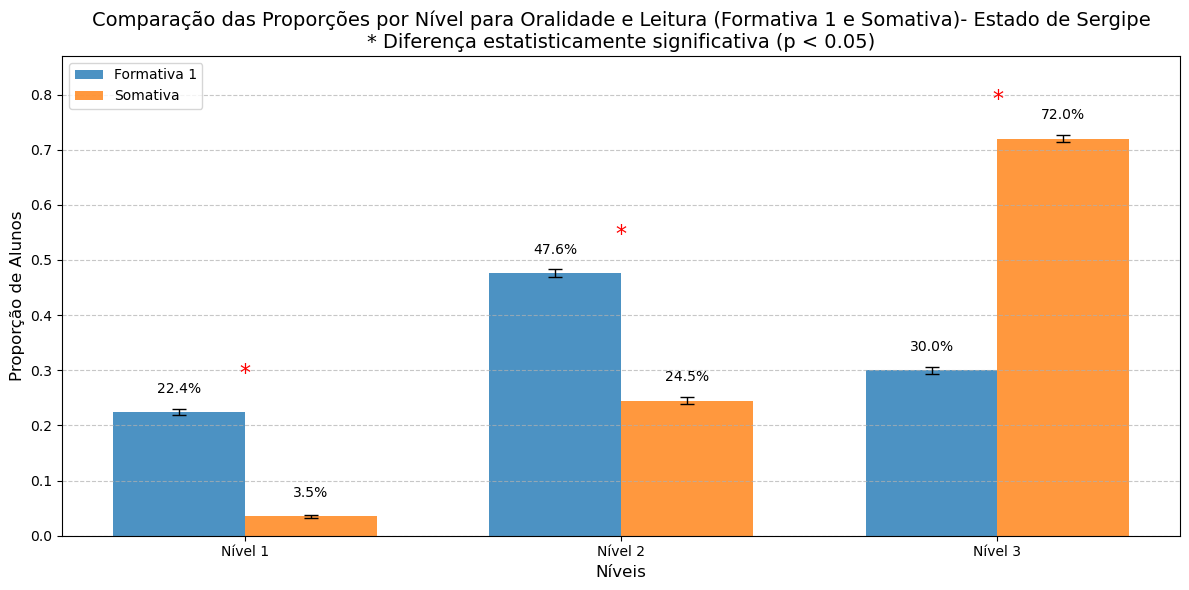

In [30]:
# Aplicando teste de Wilcoxon com função criada
#teste_wilcoxon(df_oralidade_leitura_13, 'form_1', 'form_3', output_dir_somativa, 'df_oralidade_leitura_13')
#teste_wilcoxon(df_oralidade_leitura_14, 'form_1', 'form_4', output_dir_somativa, 'df_oralidade_leitura_14')
teste_wilcoxon(df_oralidade_leitura_15, 'form_1', 'form_somativa', output_dir_somativa, 'df_oralidade_leitura_15')
#teste_wilcoxon(df_oralidade_leitura_34, 'form_3', 'form_4', output_dir_somativa, 'df_oralidade_leitura_34')
#teste_wilcoxon(df_oralidade_leitura_35, 'form_3', 'form_somativa', output_dir_somativa, 'df_oralidade_leitura_35')
#teste_wilcoxon(df_oralidade_leitura_45, 'form_4', 'form_somativa', output_dir_somativa, 'df_oralidade_leitura_45')


In [31]:
# Função para teste de Wilcoxon, criar e salvar gráficos por município
def criar_graficos_municipios(df, form_a, form_b, output_dir, df_name):
    # Agrupar dados por município
    grouped = df.groupby('municipio')
    
    for municipio, group in grouped:
        # Calcular totais para o município
        totais_municipio = {
            f'{form_a}_Nível 1': group[f'{form_a}_Nível 1'].sum(),
            f'{form_a}_Nível 2': group[f'{form_a}_Nível 2'].sum(),
            f'{form_a}_Nível 3': group[f'{form_a}_Nível 3'].sum(),
            f'{form_b}_Nível 1': group[f'{form_b}_Nível 1'].sum(),
            f'{form_b}_Nível 2': group[f'{form_b}_Nível 2'].sum(),
            f'{form_b}_Nível 3': group[f'{form_b}_Nível 3'].sum(),
            f'total_{form_a}': group[f'total_alunos_{form_a}'].sum(),
            f'total_{form_b}': group[f'total_alunos_{form_b}'].sum()
        }
        
        # Calcular proporções
        prop_form_a = [
            totais_municipio[f'{form_a}_Nível 1']/totais_municipio[f'total_{form_a}'],
            totais_municipio[f'{form_a}_Nível 2']/totais_municipio[f'total_{form_a}'],
            totais_municipio[f'{form_a}_Nível 3']/totais_municipio[f'total_{form_a}']
        ]
        
        prop_form_b = [
            totais_municipio[f'{form_b}_Nível 1']/totais_municipio[f'total_{form_b}'],
            totais_municipio[f'{form_b}_Nível 2']/totais_municipio[f'total_{form_b}'],
            totais_municipio[f'{form_b}_Nível 3']/totais_municipio[f'total_{form_b}']
        ]
        
        # Calcular erros padrão
        def calc_erro(p, n):
            return np.sqrt(p * (1 - p) / n) if n > 0 else 0
            
        erro_form_a = [calc_erro(p, totais_municipio[f'total_{form_a}']) for p in prop_form_a]
        erro_form_b = [calc_erro(p, totais_municipio[f'total_{form_b}']) for p in prop_form_b]
        
        # Criar figura
        plt.figure(figsize=(10, 6))
        
        # Configurações do gráfico
        bar_width = 0.35
        index = np.arange(3)
        
        # Tradutor de nomes de práticas de linguagem
        label_praticas = {
            'df_analise_linguistica': 'Análise Linguística',
            'df_oralidade_leitura_13':'Oralidade e Leitura',
            'df_oralidade_leitura_14':'Oralidade e Leitura',
            'df_oralidade_leitura_15':'Oralidade e Leitura',
            'df_oralidade_leitura_34':'Oralidade e Leitura',
            'df_oralidade_leitura_35':'Oralidade e Leitura',
            'df_oralidade_leitura_45':'Oralidade e Leitura',
            'df_producao_escrita_34': 'Produção Escrita',
            'df_producao_escrita_35': 'Produção Escrita',
            'df_producao_escrita_45': 'Produção Escrita'
            }
        
        # Este é o seu "tradutor" de nomes
        label_map = {'form_1': 'Formativa 1',
                     'form_2': 'Formativa 2',
                     'form_3': 'Formativa 3',
                     'form_4': 'Formativa 4',
                     'form_somativa': 'Somativa'
                     }
        
        # Buscando label no dicinário
        label_a = label_map.get(form_a, form_a)
        label_b = label_map.get(form_b, form_b)
        label_pratica_correta = label_praticas.get(df_name, df_name)
        
    
        # Criar barras
        bars1 = plt.bar(index, prop_form_a, bar_width, label=label_a, color='#1f77b4', 
                        yerr=erro_form_a, capsize=5, alpha=0.7)
    
        bars2 = plt.bar(index + bar_width, prop_form_b, bar_width, label=label_b, color='#ff7f0e',
                        yerr=erro_form_b, capsize=5, alpha=0.7)
                
        # Adicionar valores nas barras
        for bars in [bars1, bars2]:
            for bar in bars:
                height = bar.get_height()
                plt.text(bar.get_x() + bar.get_width()/2., height + 0.03,
                         f'{height:.1%}',
                         ha='center', va='bottom', fontsize=9)
        
        # Verificar significância por nível
        niveis_significativos = []
        for i, nivel in enumerate(['Nível 1', 'Nível 2', 'Nível 3']):
            if len(group) >= 3:  # Só testar se tiver turmas suficientes
                stat, p_nivel = wilcoxon(group[f'prop_{form_a}_{nivel}'], 
                                        group[f'prop_{form_b}_{nivel}'])
                if p_nivel < 0.05:
                    niveis_significativos.append(i)
                    y_pos = max(prop_form_a[i], prop_form_b[i]) + 0.05
                    plt.text(index[i] + bar_width/2, y_pos, '*', 
                            ha='center', va='bottom', fontsize=14, color='red')
            
        plt.xlabel('Níveis', fontsize=10)
        plt.ylabel('Proporção de Alunos', fontsize=10)
        plt.title(f'Comparação das Proporções por Nível para {label_pratica_correta} ({label_a} e {label_b}) - {municipio}\n* Diferença estatisticamente significativa (p < 0.05)', fontsize=12)
        plt.xticks(index + bar_width/2, ['Nível 1', 'Nível 2', 'Nível 3'])
        plt.legend()
        plt.grid(axis='y', linestyle='--', alpha=0.5)
        
        # Ajustar layout e salvar
        plt.tight_layout()
        
        # Criar nome do arquivo (substituir caracteres inválidos)
        filename = f"teste_wilcoxon_{df_name}_{municipio.replace(' ', '_').replace('/', '_')}.png"
        filepath = os.path.join(output_dir, filename)
        plt.savefig(filepath, dpi=300, bbox_inches='tight')
        plt.close()
        
        print(f"Gráfico salvo em: {filepath}")


In [32]:
# Chamar a função para criar os gráficos
#criar_graficos_municipios(df_oralidade_leitura_13, 'form_1', 'form_3', output_dir_somativa, 'df_oralidade_leitura_13')
#criar_graficos_municipios(df_oralidade_leitura_14, 'form_1', 'form_4', output_dir_somativa, 'df_oralidade_leitura_14')
criar_graficos_municipios(df_oralidade_leitura_15, 'form_1', 'form_somativa', output_dir_somativa, 'df_oralidade_leitura_15')
#criar_graficos_municipios(df_oralidade_leitura_34, 'form_3', 'form_4', output_dir_somativa, 'df_oralidade_leitura_34')
#criar_graficos_municipios(df_oralidade_leitura_35, 'form_3', 'form_somativa', output_dir_somativa, 'df_oralidade_leitura_35')
#criar_graficos_municipios(df_oralidade_leitura_45, 'form_4', 'form_somativa', output_dir_somativa, 'df_oralidade_leitura_45')

Gráfico salvo em: Data_files/graficos_somativa_348_turmas/teste_wilcoxon_df_oralidade_leitura_15_Aquidabã.png
Gráfico salvo em: Data_files/graficos_somativa_348_turmas/teste_wilcoxon_df_oralidade_leitura_15_Aracaju.png


/home/fabcmc/anaconda3/lib/python3.13/site-packages/scipy/stats/_wilcoxon.py:178: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se


Gráfico salvo em: Data_files/graficos_somativa_348_turmas/teste_wilcoxon_df_oralidade_leitura_15_Areia_Branca.png
Gráfico salvo em: Data_files/graficos_somativa_348_turmas/teste_wilcoxon_df_oralidade_leitura_15_Boquim.png
Gráfico salvo em: Data_files/graficos_somativa_348_turmas/teste_wilcoxon_df_oralidade_leitura_15_Canindé_de_São_Francisco.png
Gráfico salvo em: Data_files/graficos_somativa_348_turmas/teste_wilcoxon_df_oralidade_leitura_15_Capela.png
Gráfico salvo em: Data_files/graficos_somativa_348_turmas/teste_wilcoxon_df_oralidade_leitura_15_Carira.png
Gráfico salvo em: Data_files/graficos_somativa_348_turmas/teste_wilcoxon_df_oralidade_leitura_15_Cristinápolis.png
Gráfico salvo em: Data_files/graficos_somativa_348_turmas/teste_wilcoxon_df_oralidade_leitura_15_Estância.png
Gráfico salvo em: Data_files/graficos_somativa_348_turmas/teste_wilcoxon_df_oralidade_leitura_15_Frei_Paulo.png
Gráfico salvo em: Data_files/graficos_somativa_348_turmas/teste_wilcoxon_df_oralidade_leitura_15_In

### Produção Escrita


=== ANÁLISE CONSIDERANDO Produção Escrita (Formativa 3 E Somativa) PARA TODO O ESTADO DE SERGIPE ===


Nível 1:
Estatística = 3908.500, p-valor = 0.0000
Há diferença significativa (p < 0.05) nas proporções de Nível 1 entre os testes.
A proporção de alunos no Nível 1 DIMINUIU significativamente no teste 2.

Nível 2:
Estatística = 7365.000, p-valor = 0.0000
Há diferença significativa (p < 0.05) nas proporções de Nível 2 entre os testes.
A proporção de alunos no Nível 2 DIMINUIU significativamente no teste 2.

Nível 3:
Estatística = 5667.000, p-valor = 0.0000
Há diferença significativa (p < 0.05) nas proporções de Nível 3 entre os testes.
A proporção de alunos no Nível 3 AUMENTOU significativamente no teste 2.

=== ANÁLISE CONSIDERANDO Produção Escrita (FORMATIVAS Formativa 3 E Somativa) POR MUNICÍPIO ===


Município: Canindé de São Francisco

Nível 1:
Estatística = 5.000, p-valor = 1.0000
Não há diferença significativa (p ≥ 0.05) em Canindé de São Francisco.

Nível 2:
Estatística = 12.0

/home/fabcmc/anaconda3/lib/python3.13/site-packages/scipy/stats/_wilcoxon.py:178: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se



Nível 3:
Estatística = 0.000, p-valor = 0.0312
Há diferença significativa (p < 0.05) em Salgado.
A proporção de alunos no Nível 3 AUMENTOU significativamente no teste 2.

Município: Umbaúba

Nível 1:
Estatística = 4.000, p-valor = 0.8750
Não há diferença significativa (p ≥ 0.05) em Umbaúba.

Nível 2:
Estatística = 11.000, p-valor = 0.6875
Não há diferença significativa (p ≥ 0.05) em Umbaúba.

Nível 3:
Estatística = 11.500, p-valor = 0.4141
Não há diferença significativa (p ≥ 0.05) em Umbaúba.

Município: Estância

Nível 1:
Estatística = 0.000, p-valor = 1.0000
Não há diferença significativa (p ≥ 0.05) em Estância.

Nível 2:
Estatística = 2.000, p-valor = 0.7500
Não há diferença significativa (p ≥ 0.05) em Estância.

Nível 3:
Estatística = 1.000, p-valor = 0.5000
Não há diferença significativa (p ≥ 0.05) em Estância.

Município: Indiaroba
Número de turmas insuficiente para análise estatística.

Município: Santa Luzia do Itanhy
Número de turmas insuficiente para análise estatística.

Mu

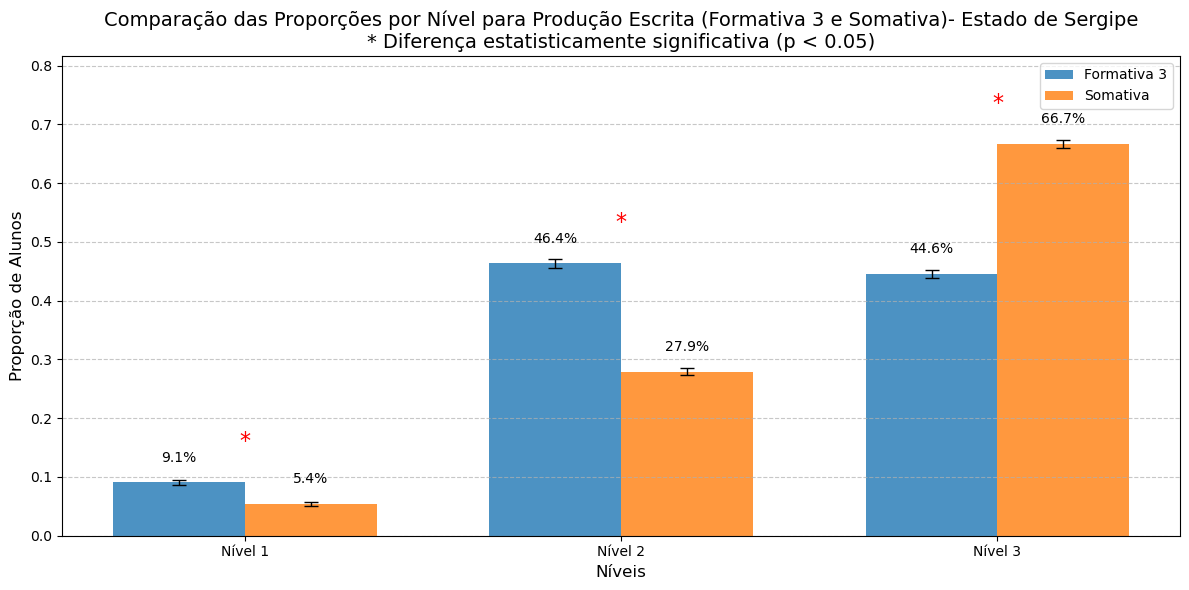

In [33]:
# Aplicando teste de Wilcoxon com função criada para Produção Escrita
#teste_wilcoxon(df_producao_escrita_34, 'form_3', 'form_4', output_dir_somativa, 'df_producao_escrita_34')
teste_wilcoxon(df_producao_escrita_35, 'form_3', 'form_somativa', output_dir_somativa, 'df_producao_escrita_35')
#teste_wilcoxon(df_producao_escrita_45, 'form_4', 'form_somativa', output_dir_somativa, 'df_producao_escrita_45')


In [34]:
# Chamar a função para criar os gráficos de produção escrita para cada municipio
#criar_graficos_municipios(df_producao_escrita_34, 'form_3', 'form_4', output_dir_somativa, 'df_producao_escrita_34')
criar_graficos_municipios(df_producao_escrita_35, 'form_3', 'form_somativa', output_dir_somativa, 'df_producao_escrita_35')
#criar_graficos_municipios(df_producao_escrita_45, 'form_4', 'form_somativa', output_dir_somativa, 'df_producao_escrita_45')

Gráfico salvo em: Data_files/graficos_somativa_348_turmas/teste_wilcoxon_df_producao_escrita_35_Aquidabã.png
Gráfico salvo em: Data_files/graficos_somativa_348_turmas/teste_wilcoxon_df_producao_escrita_35_Aracaju.png
Gráfico salvo em: Data_files/graficos_somativa_348_turmas/teste_wilcoxon_df_producao_escrita_35_Areia_Branca.png
Gráfico salvo em: Data_files/graficos_somativa_348_turmas/teste_wilcoxon_df_producao_escrita_35_Boquim.png
Gráfico salvo em: Data_files/graficos_somativa_348_turmas/teste_wilcoxon_df_producao_escrita_35_Canindé_de_São_Francisco.png
Gráfico salvo em: Data_files/graficos_somativa_348_turmas/teste_wilcoxon_df_producao_escrita_35_Capela.png
Gráfico salvo em: Data_files/graficos_somativa_348_turmas/teste_wilcoxon_df_producao_escrita_35_Carira.png


/home/fabcmc/anaconda3/lib/python3.13/site-packages/scipy/stats/_wilcoxon.py:178: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se


Gráfico salvo em: Data_files/graficos_somativa_348_turmas/teste_wilcoxon_df_producao_escrita_35_Cristinápolis.png
Gráfico salvo em: Data_files/graficos_somativa_348_turmas/teste_wilcoxon_df_producao_escrita_35_Estância.png
Gráfico salvo em: Data_files/graficos_somativa_348_turmas/teste_wilcoxon_df_producao_escrita_35_Frei_Paulo.png
Gráfico salvo em: Data_files/graficos_somativa_348_turmas/teste_wilcoxon_df_producao_escrita_35_Indiaroba.png
Gráfico salvo em: Data_files/graficos_somativa_348_turmas/teste_wilcoxon_df_producao_escrita_35_Itabaiana.png
Gráfico salvo em: Data_files/graficos_somativa_348_turmas/teste_wilcoxon_df_producao_escrita_35_Itabaianinha.png
Gráfico salvo em: Data_files/graficos_somativa_348_turmas/teste_wilcoxon_df_producao_escrita_35_Itaporanga_d'Ajuda.png
Gráfico salvo em: Data_files/graficos_somativa_348_turmas/teste_wilcoxon_df_producao_escrita_35_Japoatã.png
Gráfico salvo em: Data_files/graficos_somativa_348_turmas/teste_wilcoxon_df_producao_escrita_35_Lagarto.pn

In [35]:
# Criando função para calcular proporções de níveis por município
def calcular_proporcoes_municipios(df, form_X, form_Y):
    df_calc = df.groupby('municipio').agg({
        f'{form_X}_Nível 1': 'sum',
        f'{form_X}_Nível 2': 'sum',
        f'{form_X}_Nível 3': 'sum',
        f'{form_Y}_Nível 1': 'sum',
        f'{form_Y}_Nível 2': 'sum',
        f'{form_Y}_Nível 3': 'sum',
        f'total_alunos_{form_X}': 'sum',
        f'total_alunos_{form_Y}': 'sum'
    }).reset_index()
    
    for nivel in ['Nível 1', 'Nível 2', 'Nível 3']:
        df_calc[f'prop_{form_X}_{nivel}'] = 100 * (df_calc[f'{form_X}_{nivel}'] / df_calc[f'total_alunos_{form_X}'])
        df_calc[f'prop_{form_Y}_{nivel}'] = 100 * (df_calc[f'{form_Y}_{nivel}'] / df_calc[f'total_alunos_{form_Y}'])
        
    # Mantendo somente as colunas de proporções
    df_prop = df_calc[['municipio', f'prop_{form_X}_Nível 1', f'prop_{form_X}_Nível 2', f'prop_{form_X}_Nível 3',
                               f'prop_{form_Y}_Nível 1', f'prop_{form_Y}_Nível 2', f'prop_{form_Y}_Nível 3']]
    return df_prop
    
# Calculando proporções por município para Produção Escrita (Formativas 3 e 4) e Oralidade e Leitura (Formativas 1 e 4)
df_prop_producao_escrita_35 = calcular_proporcoes_municipios(df_producao_escrita_35, 'form_3', 'form_somativa')
df_prop_oralidade_leitura_15 = calcular_proporcoes_municipios(df_oralidade_leitura_15, 'form_1', 'form_somativa')

# Imprimindo resultados
#df_prop_oralidade_leitura_15
df_prop_producao_escrita_35

,municipio,prop_form_3_Nível 1,prop_form_3_Nível 2,prop_form_3_Nível 3,prop_form_somativa_Nível 1,prop_form_somativa_Nível 2,prop_form_somativa_Nível 3
0,Aquidabã,10.909091,50.909091,38.181818,11.111111,3.703704,85.185185
1,Aracaju,10.679612,55.201110,34.119279,6.794682,34.121123,59.084195
2,Areia Branca,5.970149,23.880597,70.149254,0.000000,8.955224,91.044776
3,Boquim,21.538462,52.307692,26.153846,9.375000,31.250000,59.375000
4,Canindé de São Francisco,12.686567,46.268657,41.044776,13.533835,38.345865,48.120301
5,Capela,6.206897,46.206897,47.586207,4.285714,17.857143,77.857143
6,Carira,15.662651,57.831325,26.506024,11.111111,16.049383,72.839506
7,Cristinápolis,13.043478,32.608696,54.347826,13.043478,15.217391,71.739130
8,Estância,2.325581,37.209302,60.465116,0.000000,33.333333,66.666667
9,Frei Paulo,14.285714,33.333333,52.380952,10.526316,52.631579,36.842105


In [36]:
# Modificando nomes de colunas para exportar tabela
novos_nomes = {
    'prop_form_1_Nível 1': 'Formativa 1 - Nível 1 (%)',
    'prop_form_1_Nível 2': 'Formativa 1 - Nível 2 (%)',
    'prop_form_1_Nível 3': 'Formativa 1 - Nível 3 (%)',
    'prop_form_2_Nível 1': 'Formativa 2 - Nível 1 (%)',
    'prop_form_2_Nível 2': 'Formativa 2 - Nível 2 (%)',
    'prop_form_2_Nível 3': 'Formativa 2 - Nível 3 (%)',
    'prop_form_3_Nível 1': 'Formativa 3 - Nível 1 (%)',
    'prop_form_3_Nível 2': 'Formativa 3 - Nível 2 (%)',
    'prop_form_3_Nível 3': 'Formativa 3 - Nível 3 (%)',
    'prop_form_4_Nível 1': 'Formativa 4 - Nível 1 (%)',
    'prop_form_4_Nível 2': 'Formativa 4 - Nível 2 (%)',
    'prop_form_4_Nível 3': 'Formativa 4 - Nível 3 (%)',
    'prop_form_somativa_Nível 1': 'Somativa - Nível 1 (%)',
    'prop_form_somativa_Nível 2': 'Somativa - Nível 2 (%)',
    'prop_form_somativa_Nível 3': 'Somativa - Nível 3 (%)'
}

df_prop_oralidade_leitura_15 = df_prop_oralidade_leitura_15.rename(columns=novos_nomes)
df_prop_producao_escrita_35 = df_prop_producao_escrita_35.rename(columns=novos_nomes)

# Exportando resultados para Excel
df_prop_oralidade_leitura_15.to_excel(f'{output_dir_somativa}/proporcoes_municipios_oralidade_leitura_15.xlsx', index=False)
df_prop_producao_escrita_35.to_excel(f'{output_dir_somativa}/proporcoes_municipios_producao_escrita_35.xlsx', index=False)


In [37]:
df_oralidade_leitura_15.head()

,turma,municipio,linguagem,form_1_Nível 1,form_1_Nível 2,form_1_Nível 3,form_somativa_Nível 1,form_somativa_Nível 2,form_somativa_Nível 3,total_alunos_form_1,total_alunos_form_somativa,prop_form_1_Nível 1,prop_form_somativa_Nível 1,prop_form_1_Nível 2,prop_form_somativa_Nível 2,prop_form_1_Nível 3,prop_form_somativa_Nível 3
0,TURMA-28000013-0001,Canindé de São Francisco,Oralidade e leitura,0.0,5.0,12.0,0.0,8.0,8.0,17.0,16.0,0.0000,0.0000,0.3125,0.5000,0.7500,0.5000
1,TURMA-28000013-0002,Canindé de São Francisco,Oralidade e leitura,1.0,12.0,5.0,1.0,6.0,9.0,18.0,16.0,0.0625,0.0625,0.7500,0.3750,0.3125,0.5625
2,TURMA-28000013-0003,Canindé de São Francisco,Oralidade e leitura,11.0,8.0,0.0,3.0,3.0,10.0,19.0,16.0,0.6875,0.1875,0.5000,0.1875,0.0000,0.6250
3,TURMA-28000013-0004,Canindé de São Francisco,Oralidade e leitura,0.0,16.0,0.0,0.0,9.0,7.0,16.0,16.0,0.0000,0.0000,1.0000,0.5625,0.0000,0.4375
4,TURMA-28000013-0005,Canindé de São Francisco,Oralidade e leitura,4.0,10.0,2.0,2.0,4.0,10.0,16.0,16.0,0.2500,0.1250,0.6250,0.2500,0.1250,0.6250
